### imports

In [1]:
# import statements --> SOME OF THESE MAY NOT BE NEEDED
%matplotlib inline 
import numpy as np 

from matplotlib import pyplot as plt 
from matplotlib.cm import get_cmap
from matplotlib.ticker import StrMethodFormatter
from matplotlib.ticker import MultipleLocator
from sklearn import neighbors
from umap.umap_ import nearest_neighbors
import pandas as pd
#import plotly
import plotly.express as px

import pickle

pd.set_option('display.max_columns', None)

#BRETT NOTEBOOK IMPORTS
from pathlib import Path

from importlib import reload
import utils
reload(utils)
from minisom import MiniSom

# imports from animation_simplified2 notebook
import seaborn as sns
sns.set(style='white', rc={'figure.figsize':(14, 12), 'animation.html': 'html5'})
import os
import copy

In [2]:
import umapz2

In [7]:
data = pd.read_parquet('som_umap_uncbudget_maps_260415.parquet')
spec95 = pd.read_parquet('spec95_ugrizyJH_maps_250819.parquet')
spec95 = spec95.drop(columns=['SOM-1', 'SOM-2', 'UMAP3D-1', 'UMAP3D-2', 'UMAP3D-3'])
spec95 = spec95[spec95['specz']>0.0]
spec95 = pd.merge(left=spec95[['ID', 'specz']], right=data, left_on='ID', right_on='ID')
spec95

,ID,specz,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,SOMrs0-1,SOMrs0-2,SOMrs1-1,SOMrs1-2,SOMrs2-1,SOMrs2-2,SOMrs3-1,SOMrs3-2,SOMrs4-1,SOMrs4-2,SOMrs5-1,SOMrs5-2,SOMrs6-1,SOMrs6-2,SOMrs7-1,SOMrs7-2,SOMrs8-1,SOMrs8-2,SOMrs9-1,SOMrs9-2,SOMrs10-1,SOMrs10-2,SOMrs11-1,SOMrs11-2,SOMrs12-1,SOMrs12-2,SOMrs13-1,SOMrs13-2,SOMrs14-1,SOMrs14-2,SOMrs15-1,SOMrs15-2,SOMrs16-1,SOMrs16-2,SOMrs17-1,SOMrs17-2,SOMrs18-1,SOMrs18-2,SOMrs19-1,SOMrs19-2,SOMrs20-1,SOMrs20-2,SOMrs21-1,SOMrs21-2,SOMrs22-1,SOMrs22-2,SOMrs23-1,SOMrs23-2,SOMrs24-1,SOMrs24-2,SOMrs25-1,SOMrs25-2,UMAPnn68-1,UMAPnn68-2,UMAPnn68-3,UMAPnn80-1,UMAPnn80-2,UMAPnn80-3,UMAPnn92-1,UMAPnn92-2,UMAPnn92-3
0,535,0.82589,150.726526,1.795723,0,3.135322,0.004911,0.001979,3.543392,0.005600,0.001707,4.149280,0.006839,0.001707,5.531073,0.006686,0.001311,9.094858,0.011055,0.001310,6.137582,0.023292,0.003891,8.654985,0.055195,0.006917,8.847195,0.061729,0.007971,10.089081,0.037653,0.004077,12.819075,0.017958,0.001854,8.697933,0.024042,0.003679,0.8165,0,NaN,28,1.85,8,1.609000e+08,0.2,1,-20.28363,-21.12927,-21.52369,9.31240,9.27122,9.34644,9.33645,1.23468,-8.087,22.659295,22.526452,22.355068,22.042977,21.503010,21.930007,21.556834,21.532986,21.390371,21.130358,21.551460,0.132843,0.171384,0.312092,0.539966,-0.426997,0.373173,0.023848,3,3,5,99,28,73,46,70,4,33,18,61,16,71,37,75,3,16,14,95,22,55,41,3,8,86,46,59,32,85,33,11,17,62,46,47,32,26,15,42,44,3,17,23,37,2,24,96,16,27,0,26,-2.187625,1.172747,0.019873,-2.010468,1.112640,0.093870,-1.927805,1.239550,0.143205
1,670,1.16549,149.730259,1.959835,0,1.941518,0.005379,0.003476,1.863746,0.004178,0.002408,2.359093,0.005581,0.002440,3.347864,0.005832,0.001883,4.712861,0.009339,0.002130,5.044670,0.019908,0.004038,5.936375,0.013675,0.002495,7.337306,0.017588,0.002736,9.483263,0.026426,0.003042,13.707825,0.014322,0.001382,12.806878,0.012845,0.001335,1.1792,0,NaN,30,1.02,10,2.273000e+08,0.3,0,-20.49749,-21.89549,-22.47231,9.79095,9.75692,9.83047,9.80739,1.80017,-7.953,23.179647,23.224033,22.968137,22.588081,22.216789,22.142918,21.966197,21.736158,21.457606,21.057579,21.131392,-0.044386,0.255896,0.380057,0.371292,0.073870,0.176721,0.230038,34,92,7,83,36,79,26,52,19,38,14,80,19,59,29,8,42,36,41,64,41,65,31,6,38,90,6,32,4,56,40,46,40,56,29,68,41,30,46,58,1,39,5,18,8,70,44,10,40,9,3,93,-1.057274,-0.347647,5.664723,-1.026085,-0.364025,5.754747,-1.012036,-0.245612,5.801317
2,692,0.30572,149.642181,2.379960,0,1.315313,0.006756,0.006467,4.484449,0.005892,0.001415,13.213070,0.007819,0.000612,24.048380,0.008534,0.000384,35.020987,0.013526,0.000416,40.134805,0.026583,0.000678,66.579523,0.061359,0.000999,98.679499,0.078428,0.000908,133.665136,0.058089,0.000475,81.719072,0.032358,0.000524,83.615927,0.028347,0.000451,0.3269,0,NaN,29,0.29,9,5.000000e+09,0.4,1,-16.72223,-20.57175,-21.94677,10.35539,10.31772,10.39305,10.38281,0.19029,-10.190,23.602427,22.270727,21.097491,20.447285,20.039179,19.891197,19.341648,18.914433,18.584955,19.119191,19.094277,1.331700,1.173237,0.650205,0.408106,0.147982,0.549549,0.427216,29,43,31,6,20,20,34,33,43,54,0,39,1,43,21,40,13,82,12,11,18,74,20,76,20,0,31,83,28,22,27,94,38,21,22,14,40,77,29,17,22,72,46,62,37,23,14,39,2,70,30,54,6.897226,6.666687,2.855976,6.828689,6.606230,2.97

In [8]:
splits = umapz2.data_split(photcat=data, speccat=spec95, valid_size=len(spec95), rs=41)

In [9]:
splits.keys()

dict_keys(['valid', 'train_lp', 'test_lp', 'train_spec', 'test_spec'])

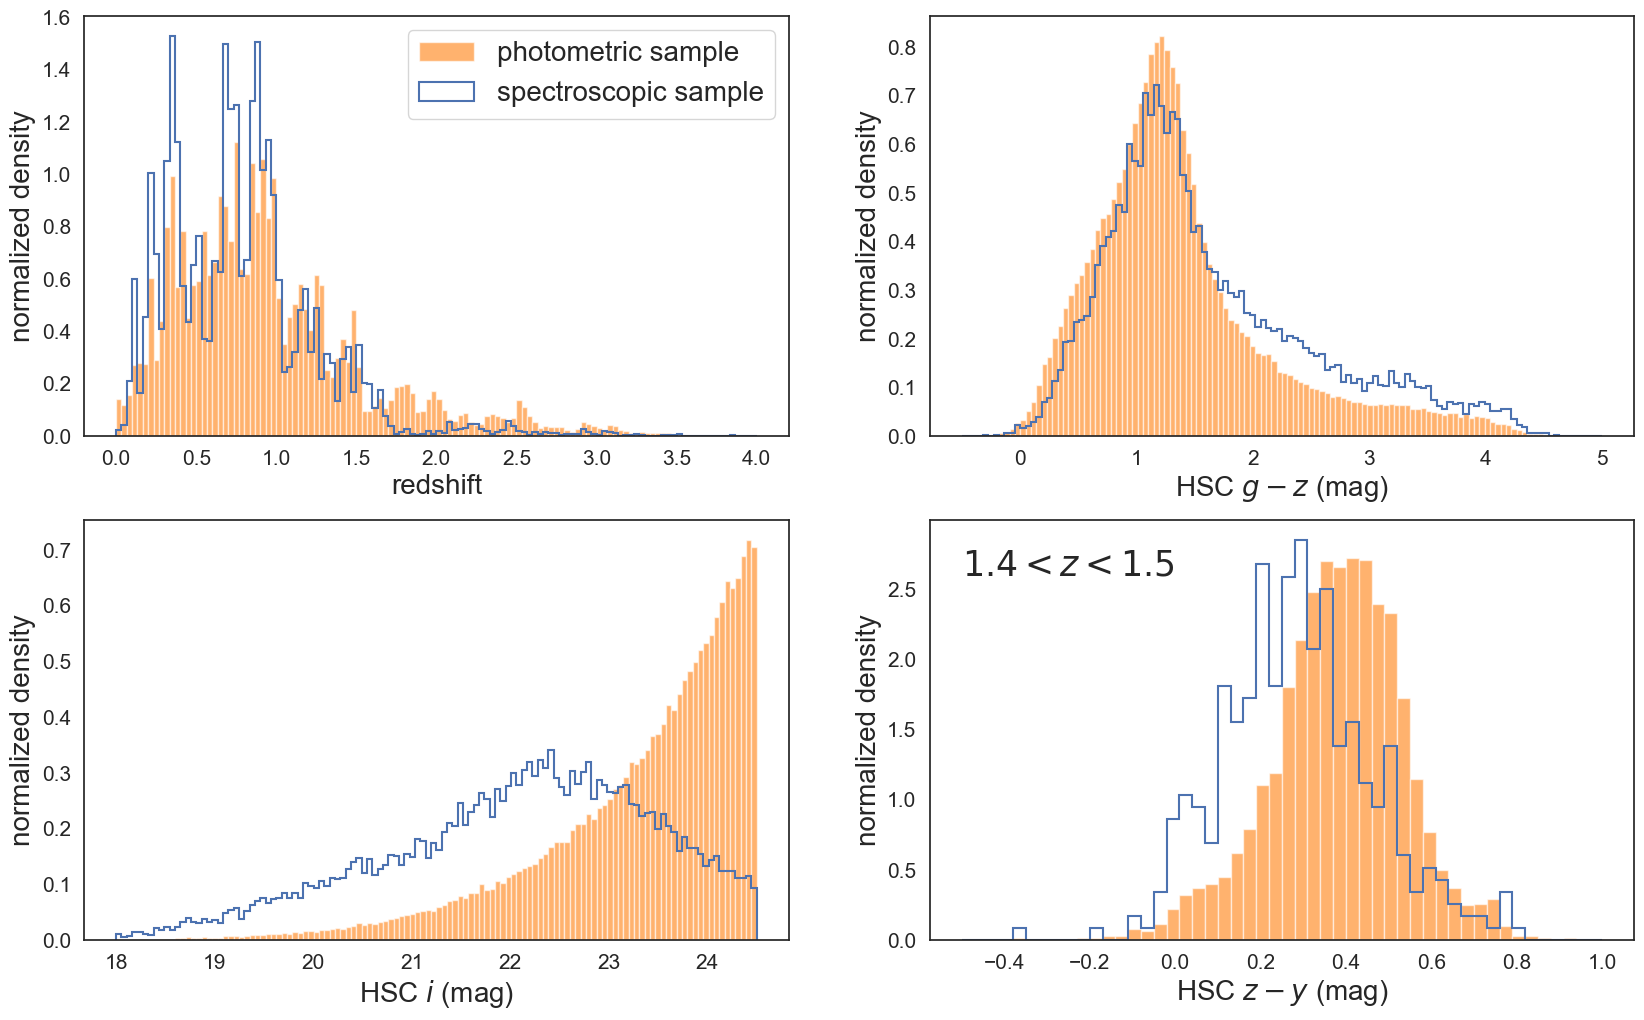

In [66]:
#umapz2.plot_distributions(phot_df=data, spec_df=spec95, filename='distributions_260522.pdf')

In [10]:
with open("som_rm_errs_260511.pkl", "rb") as f:
    som_rm_errs = pickle.load(f)

with open("som_nrm_errs_260511.pkl", "rb") as f:
    som_nrm_errs = pickle.load(f)

with open("umap_errs_260523.pkl", "rb") as f:
    umap_errs = pickle.load(f)

with open("colors_kNN_z_manhattan_errs_260513.pkl", "rb") as f:
    colors_errs = pickle.load(f)

In [8]:
splits['train_spec']

,ID,specz,RA,DEC,FLAG_COMBINED,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_u_MAGERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_g_MAGERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_r_MAGERR,HSC_i_FLUX,HSC_i_FLUXERR,HSC_i_MAGERR,HSC_z_FLUX,HSC_z_FLUXERR,HSC_z_MAGERR,HSC_y_FLUX,HSC_y_FLUXERR,HSC_y_MAGERR,UVISTA_J_FLUX,UVISTA_J_FLUXERR,UVISTA_J_MAGERR,UVISTA_H_FLUX,UVISTA_H_FLUXERR,UVISTA_H_MAGERR,UVISTA_Ks_FLUX,UVISTA_Ks_FLUXERR,UVISTA_Ks_MAGERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH1_MAGERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,IRAC_CH2_MAGERR,lp_photoz,lp_type,lp_zp_2,lp_NbFilt,lp_zq,lp_model,lp_age,lp_dust,lp_Attenuation,lp_MNUV,lp_MR,lp_MJ,lp_mass_med,lp_mass_med_min68,lp_mass_med_max68,lp_mass_best,lp_SFR_med,lp_sSFR_best,CFHT_u_MAG,HSC_g_MAG,HSC_r_MAG,HSC_i_MAG,HSC_z_MAG,HSC_y_MAG,UVISTA_J_MAG,UVISTA_H_MAG,UVISTA_Ks_MAG,IRAC_CH1_MAG,IRAC_CH2_MAG,u-g,g-r,r-i,i-z,z-y,y-J,J-H,SOMrs0-1,SOMrs0-2,SOMrs1-1,SOMrs1-2,SOMrs2-1,SOMrs2-2,SOMrs3-1,SOMrs3-2,SOMrs4-1,SOMrs4-2,SOMrs5-1,SOMrs5-2,SOMrs6-1,SOMrs6-2,SOMrs7-1,SOMrs7-2,SOMrs8-1,SOMrs8-2,SOMrs9-1,SOMrs9-2,SOMrs10-1,SOMrs10-2,SOMrs11-1,SOMrs11-2,SOMrs12-1,SOMrs12-2,SOMrs13-1,SOMrs13-2,SOMrs14-1,SOMrs14-2,SOMrs15-1,SOMrs15-2,SOMrs16-1,SOMrs16-2,SOMrs17-1,SOMrs17-2,SOMrs18-1,SOMrs18-2,SOMrs19-1,SOMrs19-2,SOMrs20-1,SOMrs20-2,SOMrs21-1,SOMrs21-2,SOMrs22-1,SOMrs22-2,SOMrs23-1,SOMrs23-2,SOMrs24-1,SOMrs24-2,SOMrs25-1,SOMrs25-2,UMAPnn68-1,UMAPnn68-2,UMAPnn68-3,UMAPnn80-1,UMAPnn80-2,UMAPnn80-3,UMAPnn92-1,UMAPnn92-2,UMAPnn92-3
0,535,0.82589,150.726526,1.795723,0,3.135322,0.004911,0.001979,3.543392,0.005600,0.001707,4.149280,0.006839,0.001707,5.531073,0.006686,0.001311,9.094858,0.011055,0.001310,6.137582,0.023292,0.003891,8.654985,0.055195,0.006917,8.847195,0.061729,0.007971,10.089081,0.037653,0.004077,12.819075,0.017958,0.001854,8.697933,0.024042,0.003679,0.8165,0,NaN,28,1.85,8,1.609000e+08,0.2,1,-20.28363,-21.12927,-21.52369,9.31240,9.27122,9.34644,9.33645,1.23468,-8.087,22.659295,22.526452,22.355068,22.042977,21.503010,21.930007,21.556834,21.532986,21.390371,21.130358,21.551460,0.132843,0.171384,0.312092,0.539966,-0.426997,0.373173,0.023848,3,3,5,99,28,73,46,70,4,33,18,61,16,71,37,75,3,16,14,95,22,55,41,3,8,86,46,59,32,85,33,11,17,62,46,47,32,26,15,42,44,3,17,23,37,2,24,96,16,27,0,26,-2.187625,1.172747,0.019873,-2.010468,1.112640,0.093870,-1.927805,1.239550,0.143205
1,670,1.16549,149.730259,1.959835,0,1.941518,0.005379,0.003476,1.863746,0.004178,0.002408,2.359093,0.005581,0.002440,3.347864,0.005832,0.001883,4.712861,0.009339,0.002130,5.044670,0.019908,0.004038,5.936375,0.013675,0.002495,7.337306,0.017588,0.002736,9.483263,0.026426,0.003042,13.707825,0.014322,0.001382,12.806878,0.012845,0.001335,1.1792,0,NaN,30,1.02,10,2.273000e+08,0.3,0,-20.49749,-21.89549,-22.47231,9.79095,9.75692,9.83047,9.80739,1.80017,-7.953,23.179647,23.224033,22.968137,22.588081,22.216789,22.142918,21.966197,21.736158,21.457606,21.057579,21.131392,-0.044386,0.255896,0.380057,0.371292,0.073870,0.176721,0.230038,34,92,7,83,36,79,26,52,19,38,14,80,19,59,29,8,42,36,41,64,41,65,31,6,38,90,6,32,4,56,40,46,40,56,29,68,41,30,46,58,1,39,5,18,8,70,44,10,40,9,3,93,-1.057274,-0.347647,5.664723,-1.026085,-0.364025,5.754747,-1.012036,-0.245612,5.801317
2,692,0.30572,149.642181,2.379960,0,1.315313,0.006756,0.006467,4.484449,0.005892,0.001415,13.213070,0.007819,0.000612,24.048380,0.008534,0.000384,35.020987,0.013526,0.000416,40.134805,0.026583,0.000678,66.579523,0.061359,0.000999,98.679499,0.078428,0.000908,133.665136,0.058089,0.000475,81.719072,0.032358,0.000524,83.615927,0.028347,0.000451,0.3269,0,NaN,29,0.29,9,5.000000e+09,0.4,1,-16.72223,-20.57175,-21.94677,10.35539,10.31772,10.39305,10.38281,0.19029,-10.190,23.602427,22.270727,21.097491,20.447285,20.039179,19.891197,19.341648,18.914433,18.584955,19.119191,19.094277,1.331700,1.173237,0.650205,0.408106,0.147982,0.549549,0.427216,29,43,31,6,20,20,34,33,43,54,0,39,1,43,21,40,13,82,12,11,18,74,20,76,20,0,31,83,28,22,27,94,38,21,22,14,40,77,29,17,22,72,46,62,37,23,14,39,2,70,30,54,6.897226,6.666687,2.855976,6.828689,6.606230,2.97

In [9]:
if 0:
    #UMAP
    rs_data = pd.read_parquet('umap_nn70_rs25_260523.parquet') # 'photo_rs25_maps.parquet' was made with n_neighbors=80
    rs_spec = pd.merge(rs_data.copy()[rs_data['ID'].isin(spec95['ID'])], spec95[['ID', 'specz']], left_on='ID', right_on='ID', how='left')
    rs_test = rs_data.copy()[rs_data['ID'].isin(splits['test_spec']['ID'])]
    rs_test_lp = rs_data.copy()[rs_data['ID'].isin(splits['test_lp']['ID'])]
    rs_train_lp = rs_data.copy()[rs_data['ID'].isin(splits['train_lp']['ID'])]

    #SOM-rm
    rs_data_som = pd.read_parquet('som_rs25_maps.parquet') # 'photo_rs25_maps.parquet' was made with n_neighbors=80
    rs_spec_somrm = pd.merge(rs_data_som.copy()[rs_data_som['ID'].isin(spec95['ID'])], spec95[['ID', 'specz']], left_on='ID', right_on='ID', how='left')
    rs_test_somrm = rs_data_som.copy()[rs_data_som['ID'].isin(splits['test_spec']['ID'])]
    rs_test_lp_somrm = rs_data_som.copy()[rs_data_som['ID'].isin(splits['test_lp']['ID'])]
    rs_train_lp_somrm = rs_data_som.copy()[rs_data_som['ID'].isin(splits['train_lp']['ID'])]
    #SOM-nrm
    rs_spec_somnrm = pd.merge(rs_data_som.copy()[rs_data_som['ID'].isin(spec95['ID'])], spec95[['ID', 'specz']], left_on='ID', right_on='ID', how='left')
    rs_test_somnrm = rs_data_som.copy()[rs_data_som['ID'].isin(splits['test_spec']['ID'])]
    rs_test_lp_somnrm = rs_data_som.copy()[rs_data_som['ID'].isin(splits['test_lp']['ID'])]
    rs_train_lp_somnrm = rs_data_som.copy()[rs_data_som['ID'].isin(splits['train_lp']['ID'])]

In [10]:
if 0:
    n_embeddings=25
    outliers_rs = []
    nmads_rs = []
    biases_rs = []

    outliers_rs_lp = []
    nmads_rs_lp = []
    biases_rs_lp = []

    outliers_rs_somrm = []
    nmads_rs_somrm = []
    biases_rs_somrm = []

    outliers_rs_lp_somrm = []
    nmads_rs_lp_somrm = []
    biases_rs_lp_somrm = []

    outliers_rs_somnrm = []
    nmads_rs_somnrm = []
    biases_rs_somnrm = []

    outliers_rs_lp_somnrm = []
    nmads_rs_lp_somnrm = []
    biases_rs_lp_somnrm = []

    # interpolate
    for i in range(n_embeddings+1):

        #UMAP
        rs_test['TEST_Zrs'+str(i)] = umapz2.interpolator(df1=rs_spec, df2=rs_test, map='UMAPrs'+str(i), dim=3, nn=15, calc='median', z_true='specz').copy()['TEST_Z']
        outliers_rs.append(umapz2.f_outlier(i_vals=rs_test['TEST_Zrs'+str(i)], t_vals=rs_test['lp_photoz'], missing=0, threshold=0.15))
        nmads_rs.append(umapz2.calc_nmad(i_vals=rs_test['TEST_Zrs'+str(i)], t_vals=rs_test['lp_photoz']))
        biases_rs.append(umapz2.calc_bias(i_vals=rs_test['TEST_Zrs'+str(i)], t_vals=rs_test['lp_photoz']))

        rs_test_lp['TEST_Zrs'+str(i)] = umapz2.interpolator(df1=rs_train_lp, df2=rs_test_lp, map='UMAPrs'+str(i), dim=3, nn=15, calc='median', z_true='lp_photoz').copy()['TEST_Z']
        outliers_rs_lp.append(umapz2.f_outlier(i_vals=rs_test_lp['TEST_Zrs'+str(i)], t_vals=rs_test_lp['lp_photoz'], missing=0, threshold=0.15))
        nmads_rs_lp.append(umapz2.calc_nmad(i_vals=rs_test_lp['TEST_Zrs'+str(i)], t_vals=rs_test_lp['lp_photoz']))
        biases_rs_lp.append(umapz2.calc_bias(i_vals=rs_test_lp['TEST_Zrs'+str(i)], t_vals=rs_test_lp['lp_photoz']))

        #SOM-rm
        rs_test_somrm['TEST_Zrs'+str(i)] = umapz2.som_rematch(df1=rs_spec_somrm, df2=rs_test_somrm, map='SOMrs'+str(i), zlabel='specz', nn=50).copy()['TEST_Z']
        outliers_rs_somrm.append(umapz2.f_outlier(i_vals=rs_test_somrm['TEST_Zrs'+str(i)], t_vals=rs_test_somrm['lp_photoz'], missing=0, threshold=0.15))
        nmads_rs_somrm.append(umapz2.calc_nmad(i_vals=rs_test_somrm['TEST_Zrs'+str(i)], t_vals=rs_test_somrm['lp_photoz']))
        biases_rs_somrm.append(umapz2.calc_bias(i_vals=rs_test_somrm['TEST_Zrs'+str(i)], t_vals=rs_test_somrm['lp_photoz']))

        rs_test_lp_somrm['TEST_Zrs'+str(i)] = umapz2.som_rematch(df1=rs_train_lp_somrm, df2=rs_test_lp_somrm, map='SOMrs'+str(i), zlabel='lp_photoz', nn=50).copy()['TEST_Z']
        outliers_rs_lp_somrm.append(umapz2.f_outlier(i_vals=rs_test_lp_somrm['TEST_Zrs'+str(i)], t_vals=rs_test_lp_somrm['lp_photoz'], missing=0, threshold=0.15))
        nmads_rs_lp_somrm.append(umapz2.calc_nmad(i_vals=rs_test_lp_somrm['TEST_Zrs'+str(i)], t_vals=rs_test_lp_somrm['lp_photoz']))
        biases_rs_lp_somrm.append(umapz2.calc_bias(i_vals=rs_test_lp_somrm['TEST_Zrs'+str(i)], t_vals=rs_test_lp_somrm['lp_photoz']))

        #SOM-nrm
        rs_test_somnrm['TEST_Zrs'+str(i)] = umapz2.interpolator(df1=rs_spec_somnrm, df2=rs_test_somnrm, map='SOMrs'+str(i), dim=2, nn=50, calc='median', z_true='specz').copy()['TEST_Z']
        rs_test_i_somnrm = rs_test_somnrm.loc[rs_test_somnrm['TEST_Zrs'+str(i)].copy().dropna().index.values]

        outliers_rs_somnrm.append(umapz2.f_outlier(i_vals=rs_test_i_somnrm['TEST_Zrs'+str(i)], t_vals=rs_test_i_somnrm['lp_photoz'], missing=0, threshold=0.15))
        nmads_rs_somnrm.append(umapz2.calc_nmad(i_vals=rs_test_i_somnrm['TEST_Zrs'+str(i)], t_vals=rs_test_i_somnrm['lp_photoz']))
        biases_rs_somnrm.append(umapz2.calc_bias(i_vals=rs_test_i_somnrm['TEST_Zrs'+str(i)], t_vals=rs_test_i_somnrm['lp_photoz']))

        rs_test_lp_somnrm['TEST_Zrs'+str(i)] = umapz2.interpolator(df1=rs_train_lp_somnrm, df2=rs_test_lp_somnrm, map='SOMrs'+str(i), dim=2, nn=50, calc='median', z_true='lp_photoz').copy()['TEST_Z']
        rs_test_lp_i_somnrm = rs_test_lp_somnrm.loc[rs_test_lp_somnrm['TEST_Zrs'+str(i)].copy().dropna().index.values]

        outliers_rs_lp_somnrm.append(umapz2.f_outlier(i_vals=rs_test_lp_i_somnrm['TEST_Zrs'+str(i)], t_vals=rs_test_lp_i_somnrm['lp_photoz'], missing=0, threshold=0.15))
        nmads_rs_lp_somnrm.append(umapz2.calc_nmad(i_vals=rs_test_lp_i_somnrm['TEST_Zrs'+str(i)], t_vals=rs_test_lp_i_somnrm['lp_photoz']))
        biases_rs_lp_somnrm.append(umapz2.calc_bias(i_vals=rs_test_lp_i_somnrm['TEST_Zrs'+str(i)], t_vals=rs_test_lp_i_somnrm['lp_photoz']))
        rs_test_i, rs_test_lp_i, rs_test_i_somrm, rs_test_lp_i_somrm, rs_test_i_somnrm, rs_test_lp_i_somnrm = [], [], [], [], [], []

In [11]:
if 0:    
    # UMAP
    testcats_rs = []
    testcats_rs_lp = []
    # SOM-rm
    testcats_rs_somrm = []
    testcats_rs_lp_somrm = []
    # SOM-nrm
    testcats_rs_somnrm = []
    testcats_rs_lp_somnrm = []

    for i in range(1,n_embeddings+1): 
        testcat_i = rs_test.copy()[['lp_photoz', 'TEST_Zrs'+str(i)]]
        testcat_i['TEST_Z'] = testcat_i['TEST_Zrs'+str(i)]
        testcats_rs.append(testcat_i.copy())
        testcat_i_lp = rs_test_lp.copy()[['lp_photoz', 'TEST_Zrs'+str(i)]]
        testcat_i_lp['TEST_Z'] = testcat_i_lp['TEST_Zrs'+str(i)]
        testcats_rs_lp.append(testcat_i_lp.copy())

        testcat_i_somrm = rs_test_somrm.copy()[['lp_photoz', 'TEST_Zrs'+str(i)]]
        testcat_i_somrm['TEST_Z'] = testcat_i_somrm['TEST_Zrs'+str(i)]
        testcats_rs_somrm.append(testcat_i_somrm.copy())
        testcat_i_lp_somrm = rs_test_lp_somrm.copy()[['lp_photoz', 'TEST_Zrs'+str(i)]]
        testcat_i_lp_somrm['TEST_Z'] = testcat_i_lp_somrm['TEST_Zrs'+str(i)]
        testcats_rs_lp_somrm.append(testcat_i_lp_somrm.copy())

        testcat_i_somnrm = rs_test_somnrm.copy()[['lp_photoz', 'TEST_Zrs'+str(i)]].loc[rs_test_somnrm['TEST_Zrs'+str(i)].copy().dropna().index.values]
        testcat_i_somnrm['TEST_Z'] = testcat_i_somnrm['TEST_Zrs'+str(i)]
        testcats_rs_somnrm.append(testcat_i_somnrm.copy())
        testcat_i_lp_somnrm = rs_test_lp_somnrm.copy()[['lp_photoz', 'TEST_Zrs'+str(i)]].loc[rs_test_lp_somnrm['TEST_Zrs'+str(i)].copy().dropna().index.values]
        testcat_i_lp_somnrm['TEST_Z'] = testcat_i_lp_somnrm['TEST_Zrs'+str(i)]
        testcats_rs_lp_somnrm.append(testcat_i_lp_somnrm.copy())
        testcat_i, testcat_i_lp, testcat_i_somrm, testcat_i_lp_somrm, testcat_i_somnrm, testcat_i_lp_somnrm = [], [], [], [], [], []



    rs_binned_results = umapz2.binned_stats_ensemble(fullcats=testcats_rs, testcats=testcats_rs, iv='TEST_Z', tv='lp_photoz', bin_var='lp_photoz',
                                bin_min=0.0, bin_max=3.0, bin_size=0.2)
    rs_binned_results_lp = umapz2.binned_stats_ensemble(fullcats=testcats_rs_lp, testcats=testcats_rs_lp, iv='TEST_Z', tv='lp_photoz', bin_var='lp_photoz',
                                bin_min=0.0, bin_max=3.0, bin_size=0.2)

    rs_binned_results_somrm = umapz2.binned_stats_ensemble(fullcats=testcats_rs_somrm, testcats=testcats_rs_somrm, iv='TEST_Z', tv='lp_photoz', bin_var='lp_photoz',
                                bin_min=0.0, bin_max=3.0, bin_size=0.2)
    rs_binned_results_lp_somrm = umapz2.binned_stats_ensemble(fullcats=testcats_rs_lp_somrm, testcats=testcats_rs_lp_somrm, iv='TEST_Z', tv='lp_photoz', bin_var='lp_photoz',
                                bin_min=0.0, bin_max=3.0, bin_size=0.2)

    rs_binned_results_somnrm = umapz2.binned_stats_ensemble(fullcats=testcats_rs_somnrm, testcats=testcats_rs_somnrm, iv='TEST_Z', tv='lp_photoz', bin_var='lp_photoz',
                                bin_min=0.0, bin_max=3.0, bin_size=0.2)
    rs_binned_results_lp_somnrm = umapz2.binned_stats_ensemble(fullcats=testcats_rs_lp_somnrm, testcats=testcats_rs_lp_somnrm, iv='TEST_Z', tv='lp_photoz', bin_var='lp_photoz',
                                bin_min=0.0, bin_max=3.0, bin_size=0.2)

In [12]:
#with open("rs_binned_results_umap_s_260422.pkl", "wb") as f:
#    pickle.dump(rs_binned_results, f)

#with open("rs_binned_results_umap_lp_260422.pkl", "wb") as f:
#    pickle.dump(rs_binned_results_lp, f)

#with open("rs_binned_results_somrm_s_260422.pkl", "wb") as f:
#    pickle.dump(rs_binned_results_somrm, f)

#with open("rs_binned_results_somrm_lp_260422.pkl", "wb") as f:
#    pickle.dump(rs_binned_results_lp_somrm, f)

#with open("rs_binned_results_somnrm_s_260422.pkl", "wb") as f:
#    pickle.dump(rs_binned_results_somnrm, f)

#with open("rs_binned_results_somnrm_lp_260422.pkl", "wb") as f:
#    pickle.dump(rs_binned_results_lp_somnrm, f)

### skip to here

In [3]:
with open("somtco_binned_260518.pkl", "rb") as f:
    somtco_perf = pickle.load(f)

with open("somrm_binned_260518.pkl", "rb") as f:
    somrm_perf = pickle.load(f)

with open("umap_binned_260523.pkl", "rb") as f:
    umap_perf = pickle.load(f)

with open("colors_binned_260513.pkl", "rb") as f:
    colors_perf = pickle.load(f)

In [4]:
with open("som_rm_errs_260511.pkl", "rb") as f:
    somrm_errs = pickle.load(f)

with open("som_nrm_errs_260511.pkl", "rb") as f:
    somtco_errs = pickle.load(f)

with open("umap_errs_260523.pkl", "rb") as f:
    umap_errs = pickle.load(f)

with open("colors_kNN_z_manhattan_errs_260513.pkl", "rb") as f:
    colors_errs = pickle.load(f)

In [5]:
umap_errs.keys()

dict_keys(['outliers', 'nmads', 'biases', 'outliers_lp', 'nmads_lp', 'biases_lp'])

In [6]:
somrm_perf['LePHARE_trained']['f_outlier'].keys()

dict_keys(['mean', 'unc_size', 'unc_sigma', 'unc_learning_rate', 'unc_rs', 'unc_boots', 'unc'])

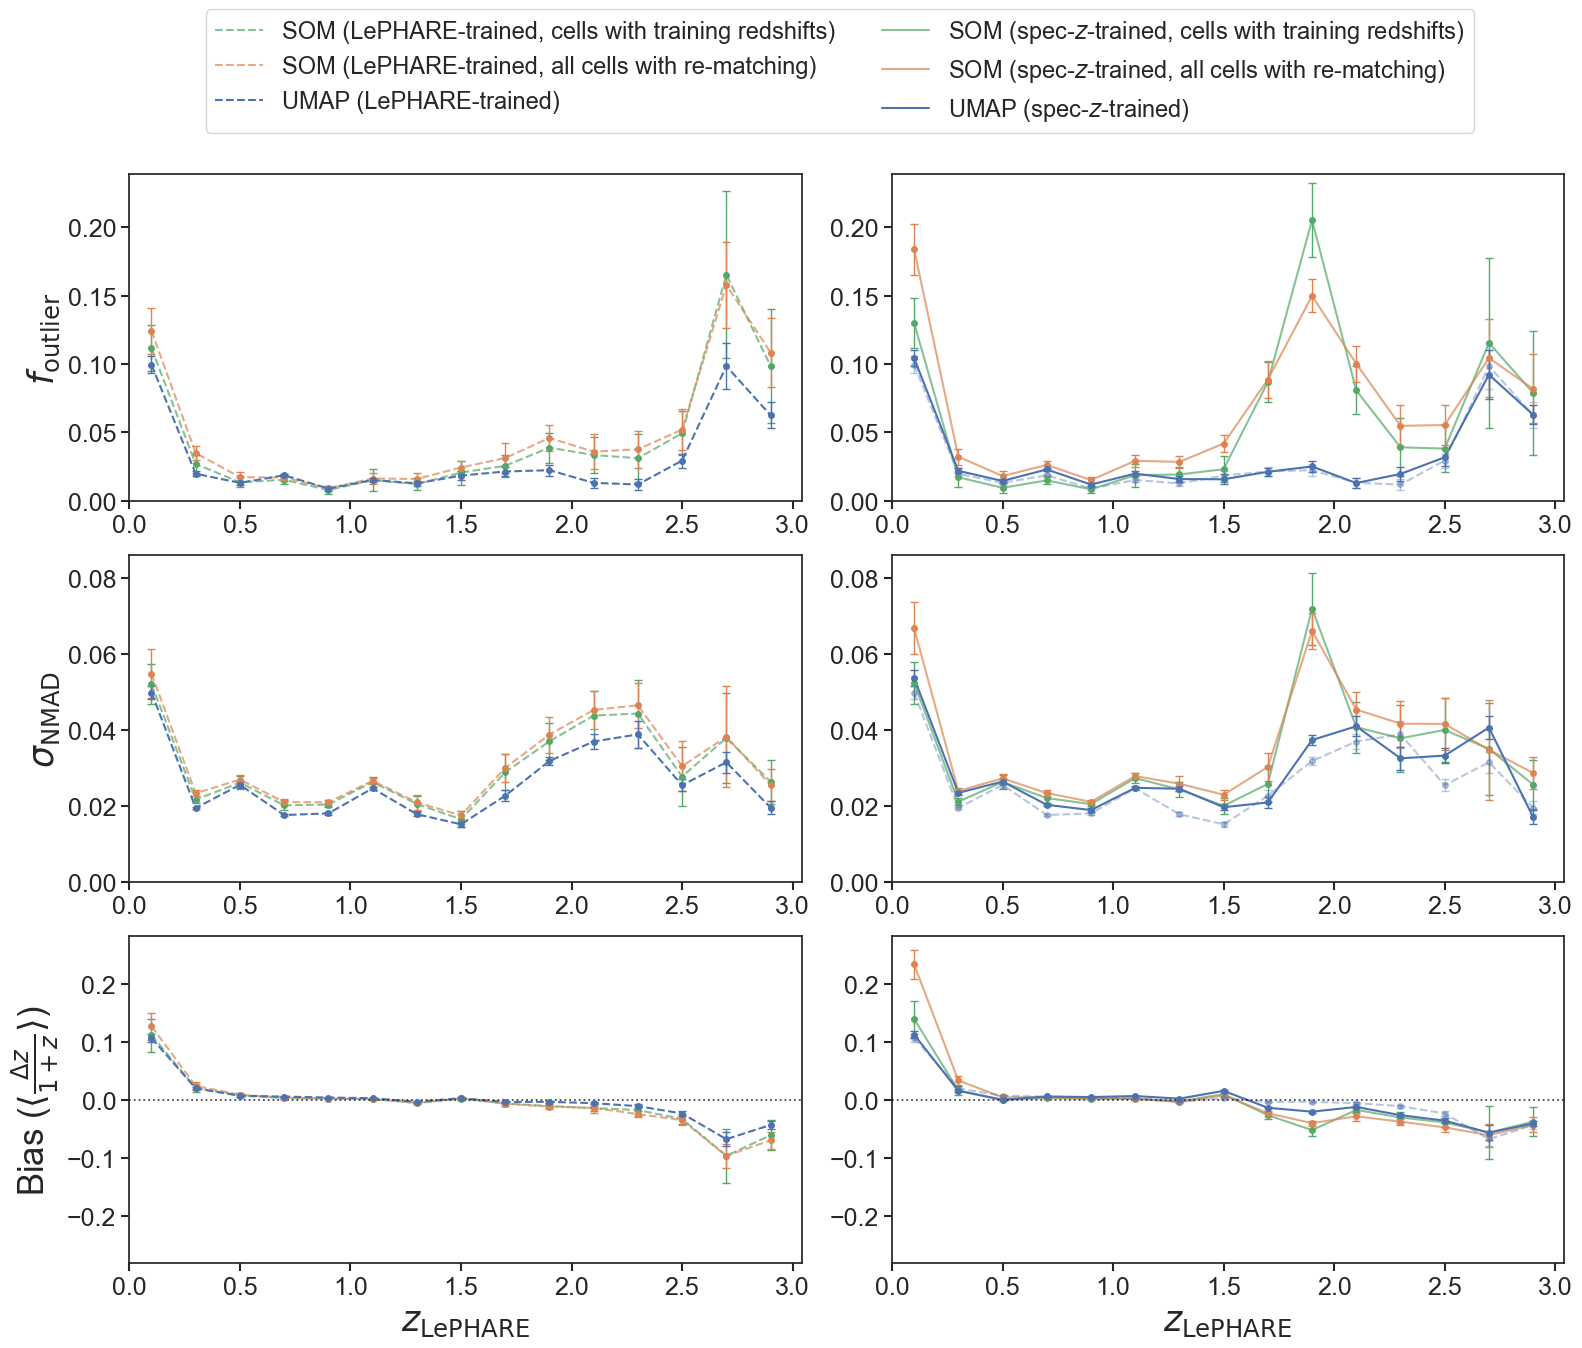

In [175]:
reload(umapz2)
umapz2.z_binned_stats3(somrm_perf=somrm_perf, somtco_perf=somtco_perf, umap_perf=umap_perf,
                       filename='zbinned_umap_vs_som_260628.pdf')

### sandplots

In [13]:
print(somrm_perf['specz_trained']['f_outlier'].keys())
print(somtco_perf['specz_trained']['f_outlier'].keys())
print(umap_perf['specz_trained']['f_outlier'].keys())
print(colors_perf['specz_trained']['f_outlier'].keys())

dict_keys(['mean', 'unc_size', 'unc_sigma', 'unc_learning_rate', 'unc_rs', 'unc_boots'])
dict_keys(['mean', 'unc_size', 'unc_sigma', 'unc_learning_rate', 'unc_rs', 'unc_boots'])
dict_keys(['mean', 'unc', 'unc_k', 'unc_nn', 'unc_rs', 'unc_boots'])
dict_keys(['f_outlier', 'unc_k', 'unc_boots'])


In [53]:
labels = ['embedding random seed','finite test set','size choice','sigma choice','learning_rate choice']
cs = ['blue', 'r', 'g', '0.2', 'orange']
uncs = somrm_perf
unc_sources = ['rs', 'boots', 'size', 'sigma', 'learning_rate']
ylims = [0.14, 0.03, 0.1]

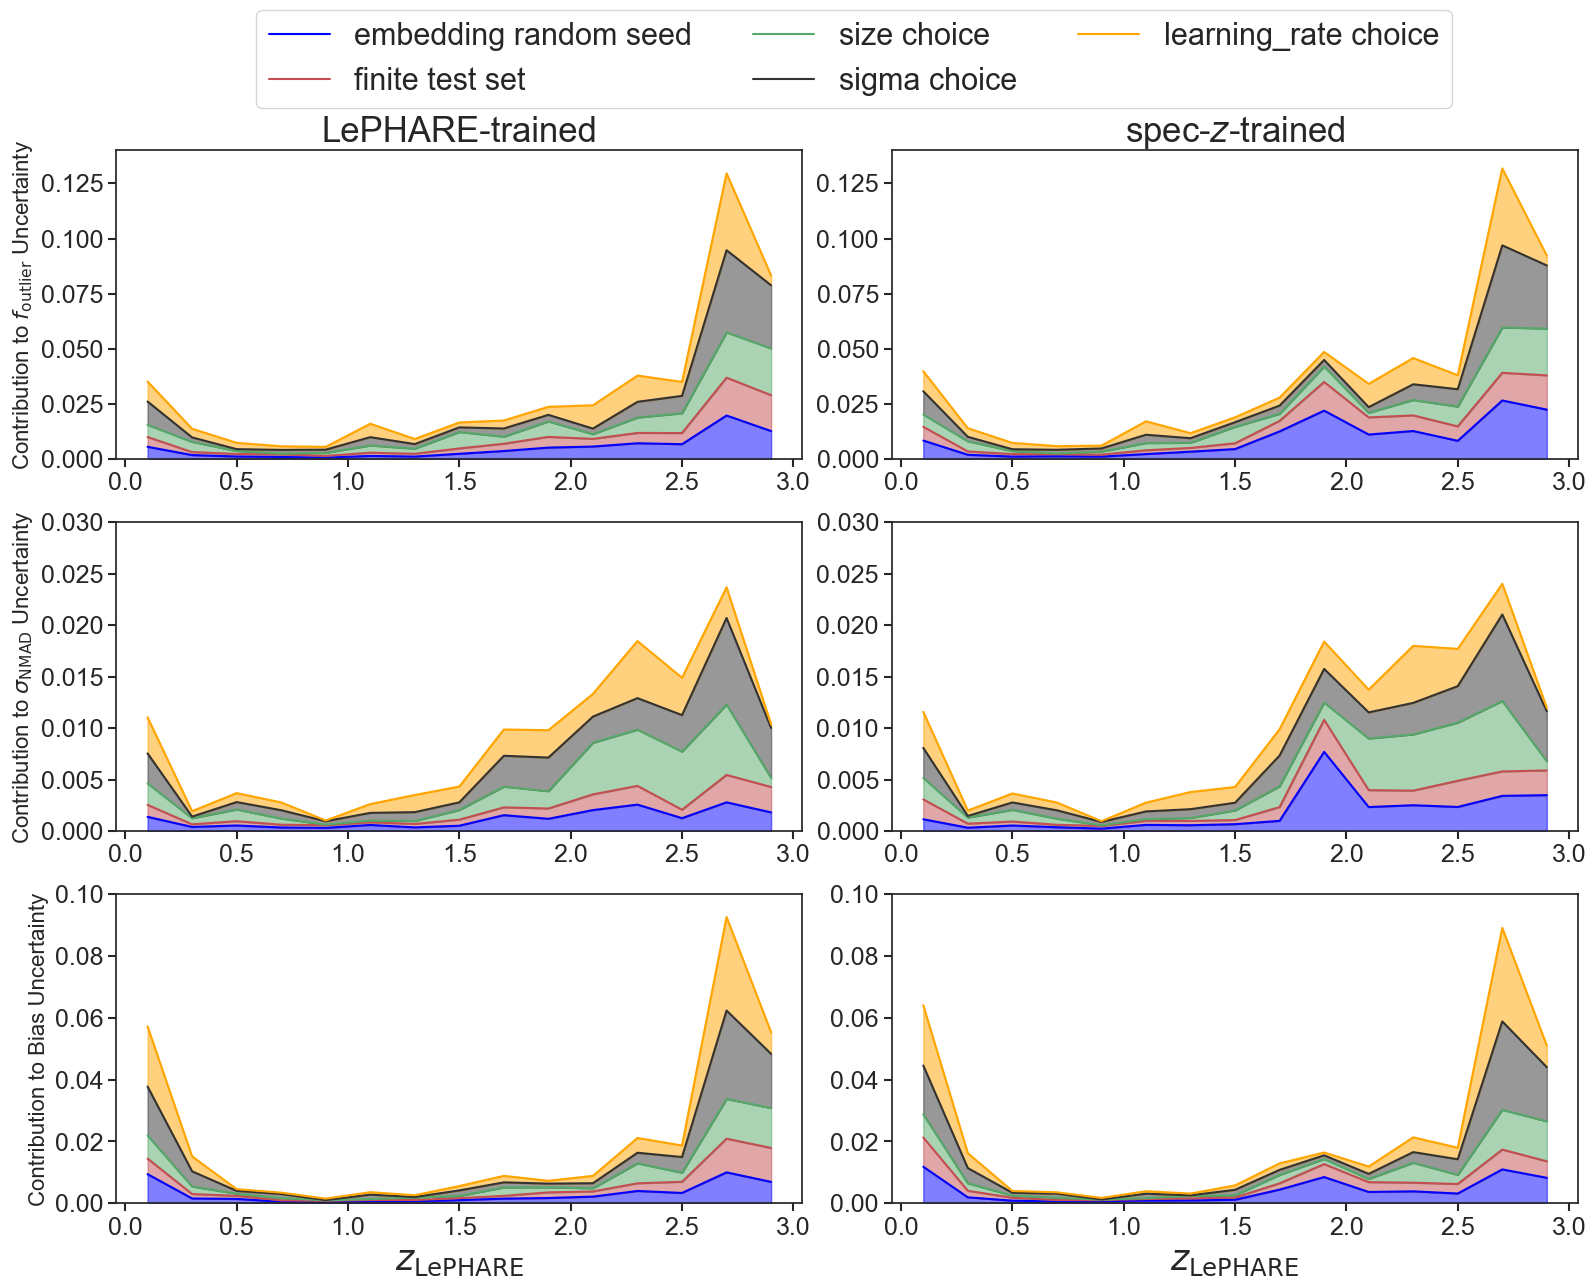

In [ ]:
reload(umapz2)
umapz2.sandplot_som(uncs=somtco_perf, unc_sources=unc_sources, labels=labels, 
                    cs=cs, ylims=ylims)#, filename='somz_sandplot.pdf')

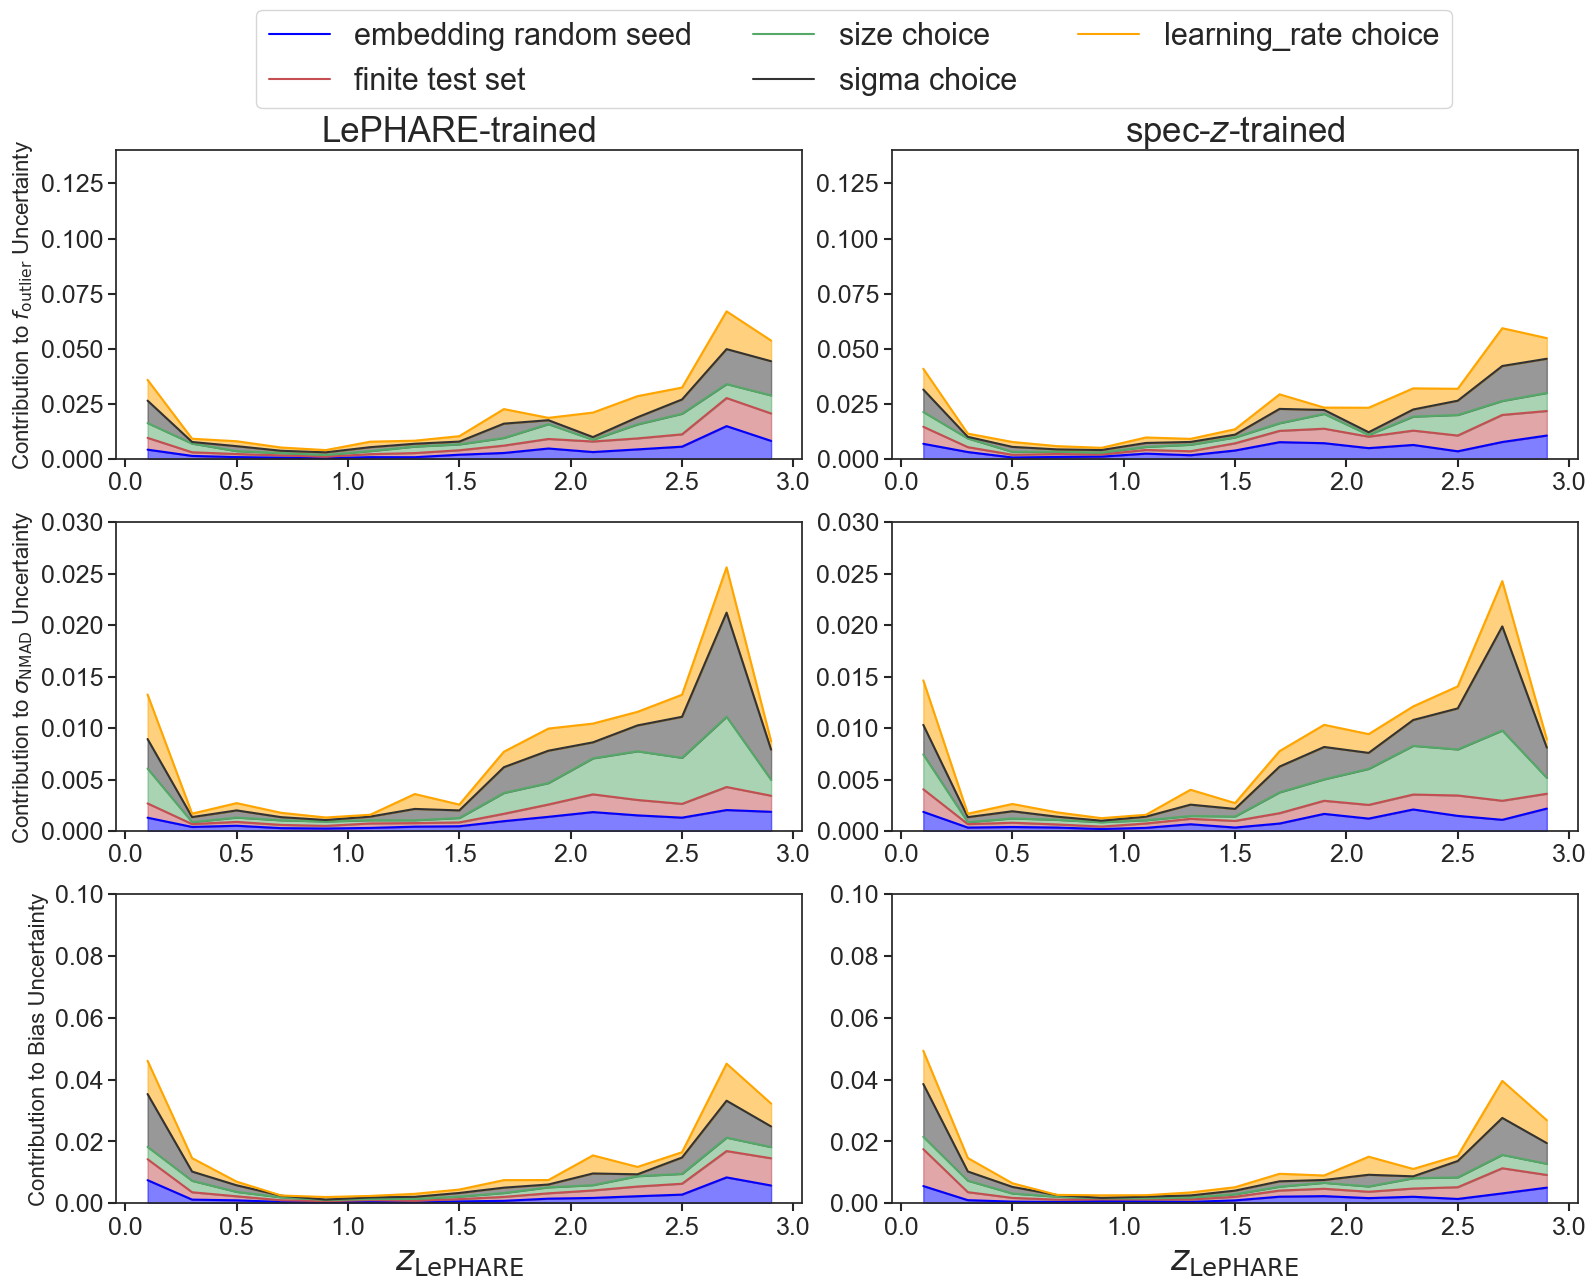

In [55]:
reload(umapz2)
umapz2.sandplot_som(uncs=somrm_perf, unc_sources=unc_sources, labels=labels, 
                    cs=cs, ylims=ylims)#, filename='nearestz_sandplot.pdf')

In [81]:
cs = ['r', '0.2', 'g', 'blue']
labels = ['finite test set', 'n_neighbors choice', 'k-value choice','embedding random seed']
unc_sources = ['boots', 'nn', 'k', 'rs']
ylims = [0.14, 0.03, 0.1]

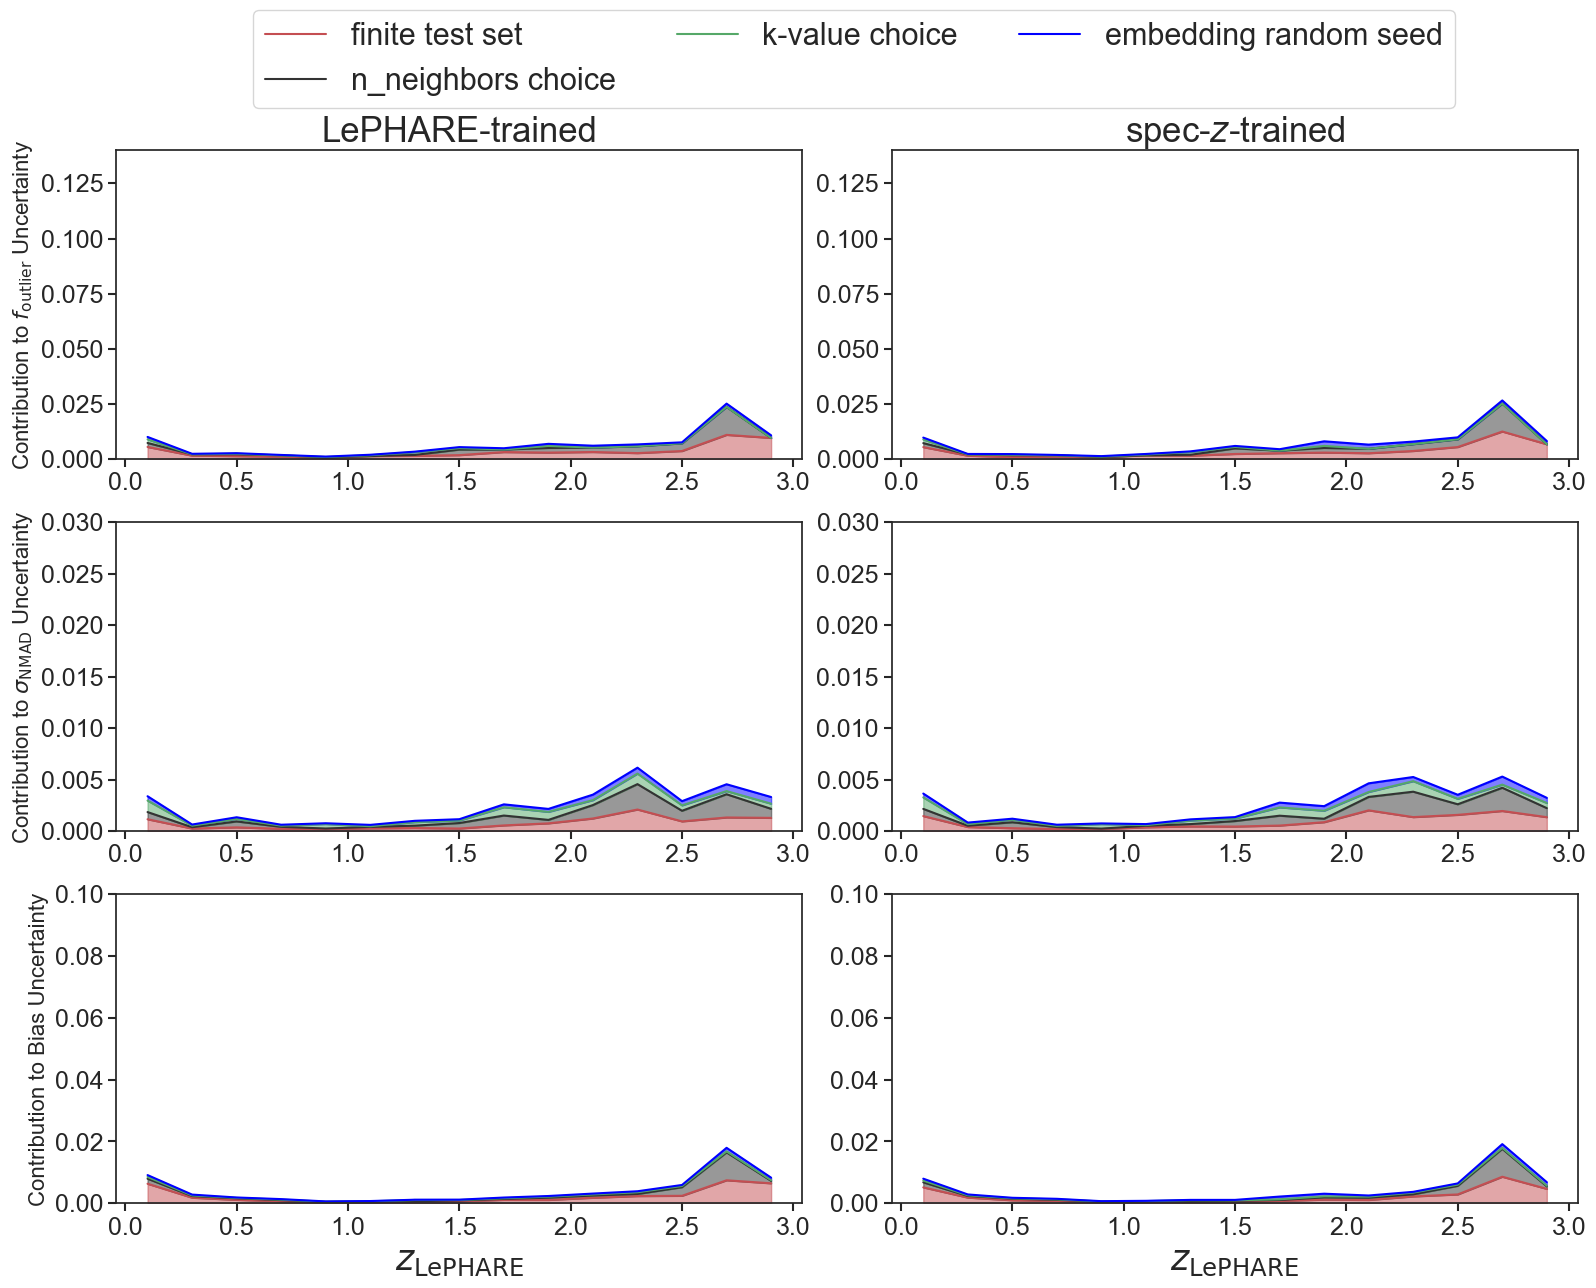

In [82]:
reload(umapz2)
umapz2.sandplot_umap(uncs=umap_perf, unc_sources=unc_sources, labels=labels, 
                    cs=cs, ylims=ylims, filename='umapz_sandplot_260524.pdf')

In [58]:
cs = ['r', 'g']
labels = ['finite test set', 'k-value choice']
unc_sources = ['boots', 'k']
ylims = [0.14, 0.03, 0.1]

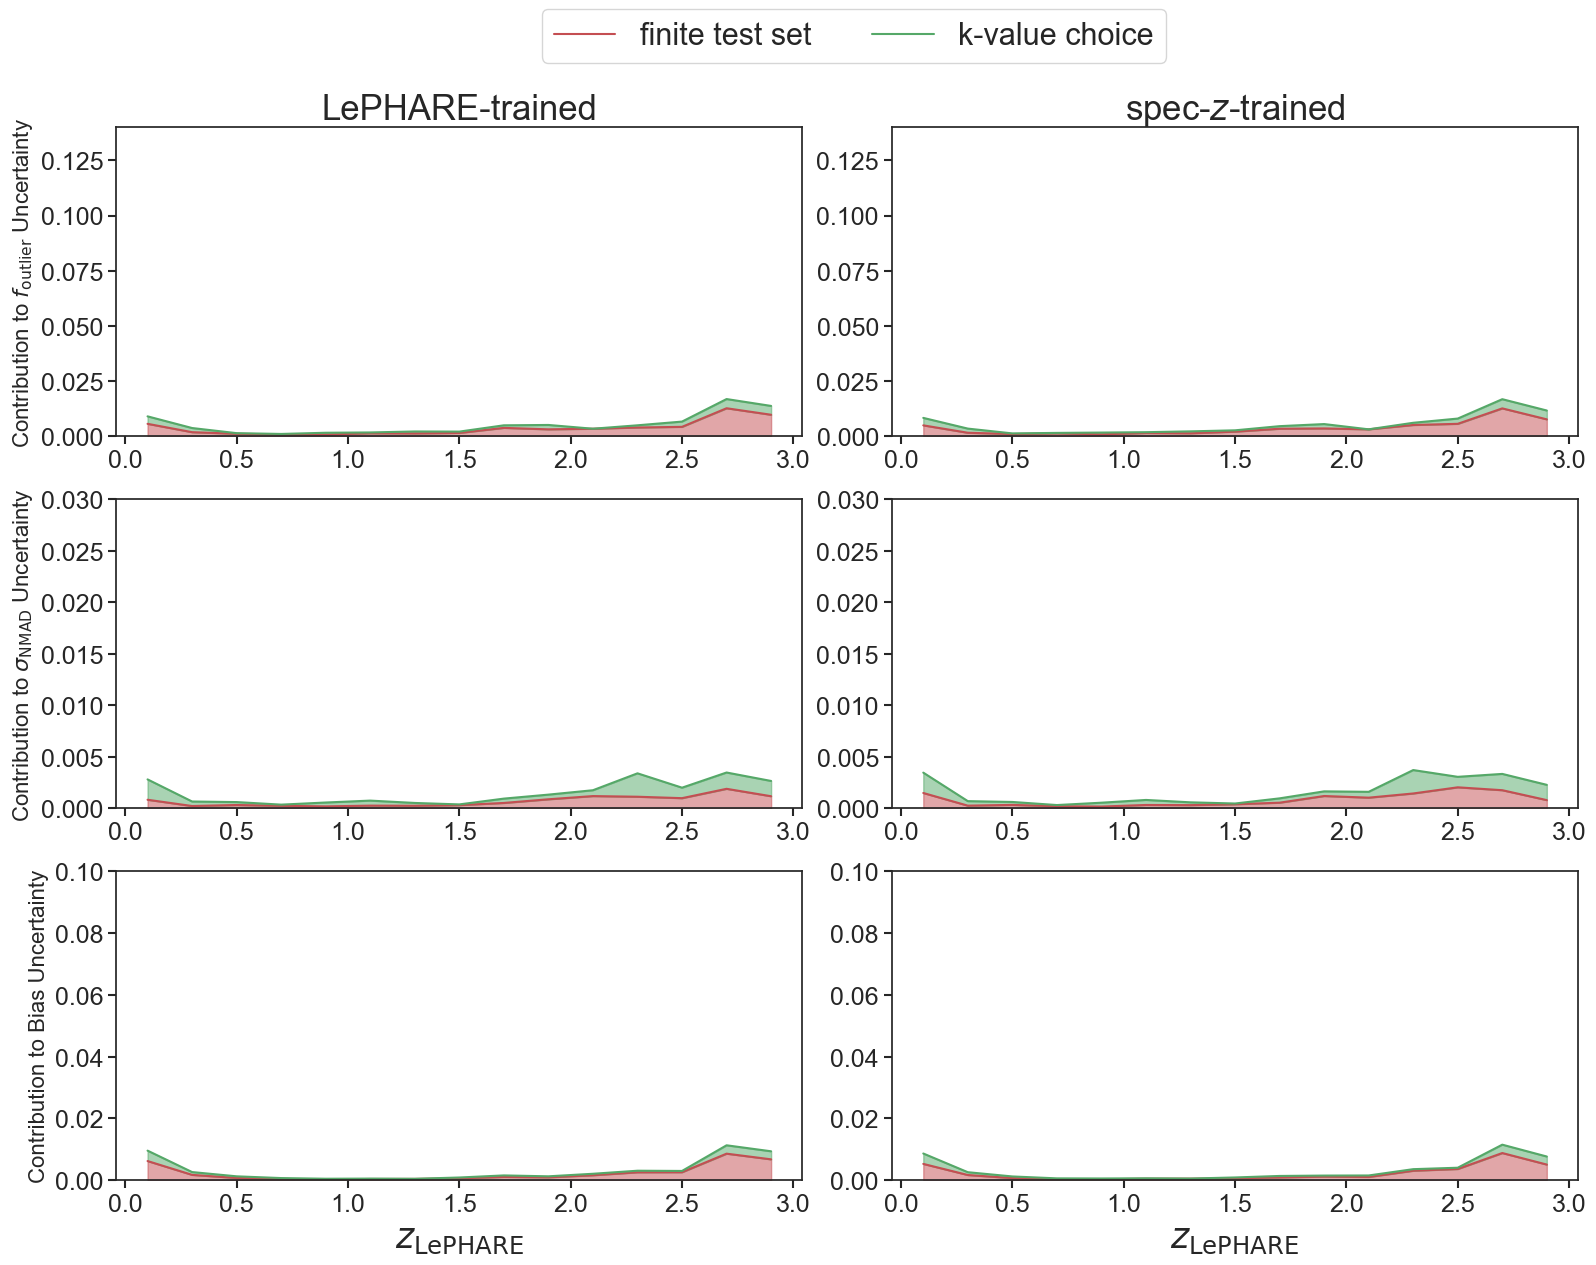

In [59]:
reload(umapz2)
umapz2.sandplot_colors(uncs=colors_perf, unc_sources=unc_sources, labels=labels, 
                    cs=cs, ylims=ylims)#, filename='colorsz_sandplot.pdf')

### Rachel plots

In [123]:
labels = ['finite test set', 'k-value choice']
cs = ['C1', 'C2']
unc_sources = ['boots', 'k']
ylims = [0.042, 0.014, 0.038]

In [170]:
umap_perf['specz_trained']['f_outlier']['unc_nn']

array([0.00181231, 0.00057239, 0.00081381, 0.00060482, 0.        ,
       0.        , 0.00039683, 0.00252893, 0.00116279, 0.00210526,
       0.002     , 0.003125  , 0.00351852, 0.01268074, 0.        ])

In [171]:
umap_perf['specz_trained']['f_outlier']['unc_boots']

array([0.00546734, 0.00157643, 0.00093684, 0.00113799, 0.00096741,
       0.00176647, 0.0015884 , 0.00236035, 0.00271228, 0.00299203,
       0.00270523, 0.00371144, 0.00550082, 0.01253526, 0.00675569])

In [168]:
colors_perf['specz_trained']['f_outlier']['unc_boots']

array([0.00490693, 0.00155533, 0.00097794, 0.0012765 , 0.0008275 ,
       0.00143927, 0.00130953, 0.00206178, 0.00337846, 0.00350949,
       0.00310643, 0.00507192, 0.00560352, 0.01260135, 0.00763025])

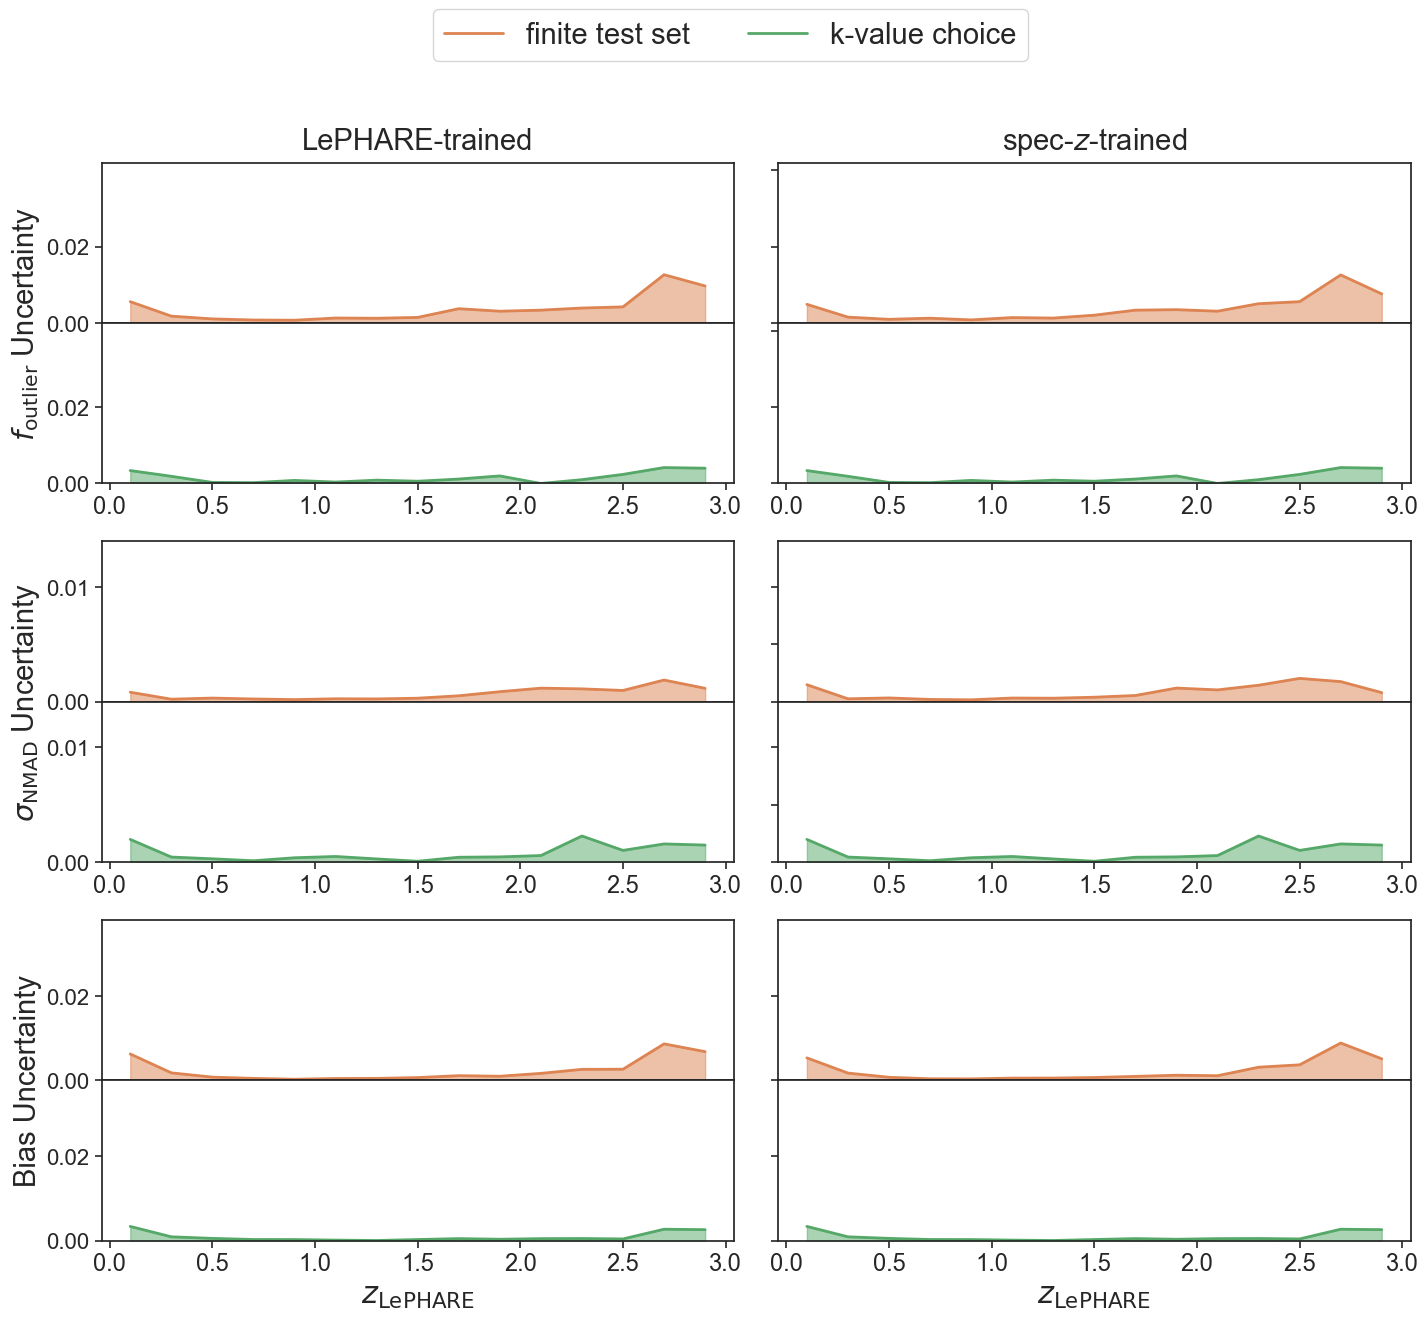

In [124]:
reload(umapz2)
umapz2.sandplot_split(uncs=colors_perf, unc_sources=unc_sources, labels=labels, 
                    cs=cs, ylims=ylims, filename='colors_uncs_260623.pdf')

In [125]:
#labels = ['embedding random seed','finite test set','size choice','sigma choice','learning_rate choice']
#cs = ['C0', 'C1', 'C2', 'C3', 'C4']
#unc_sources = ['rs', 'boots', 'size', 'sigma', 'learning_rate']

In [126]:
labels = ['embedding random seed', 'finite test set', 'k-value choice', 'n_neighbors choice']
cs = ['C0', 'C1', 'C2', 'C3']
unc_sources = ['rs', 'boots', 'k', 'nn']
ylims = [0.042, 0.014, 0.038]

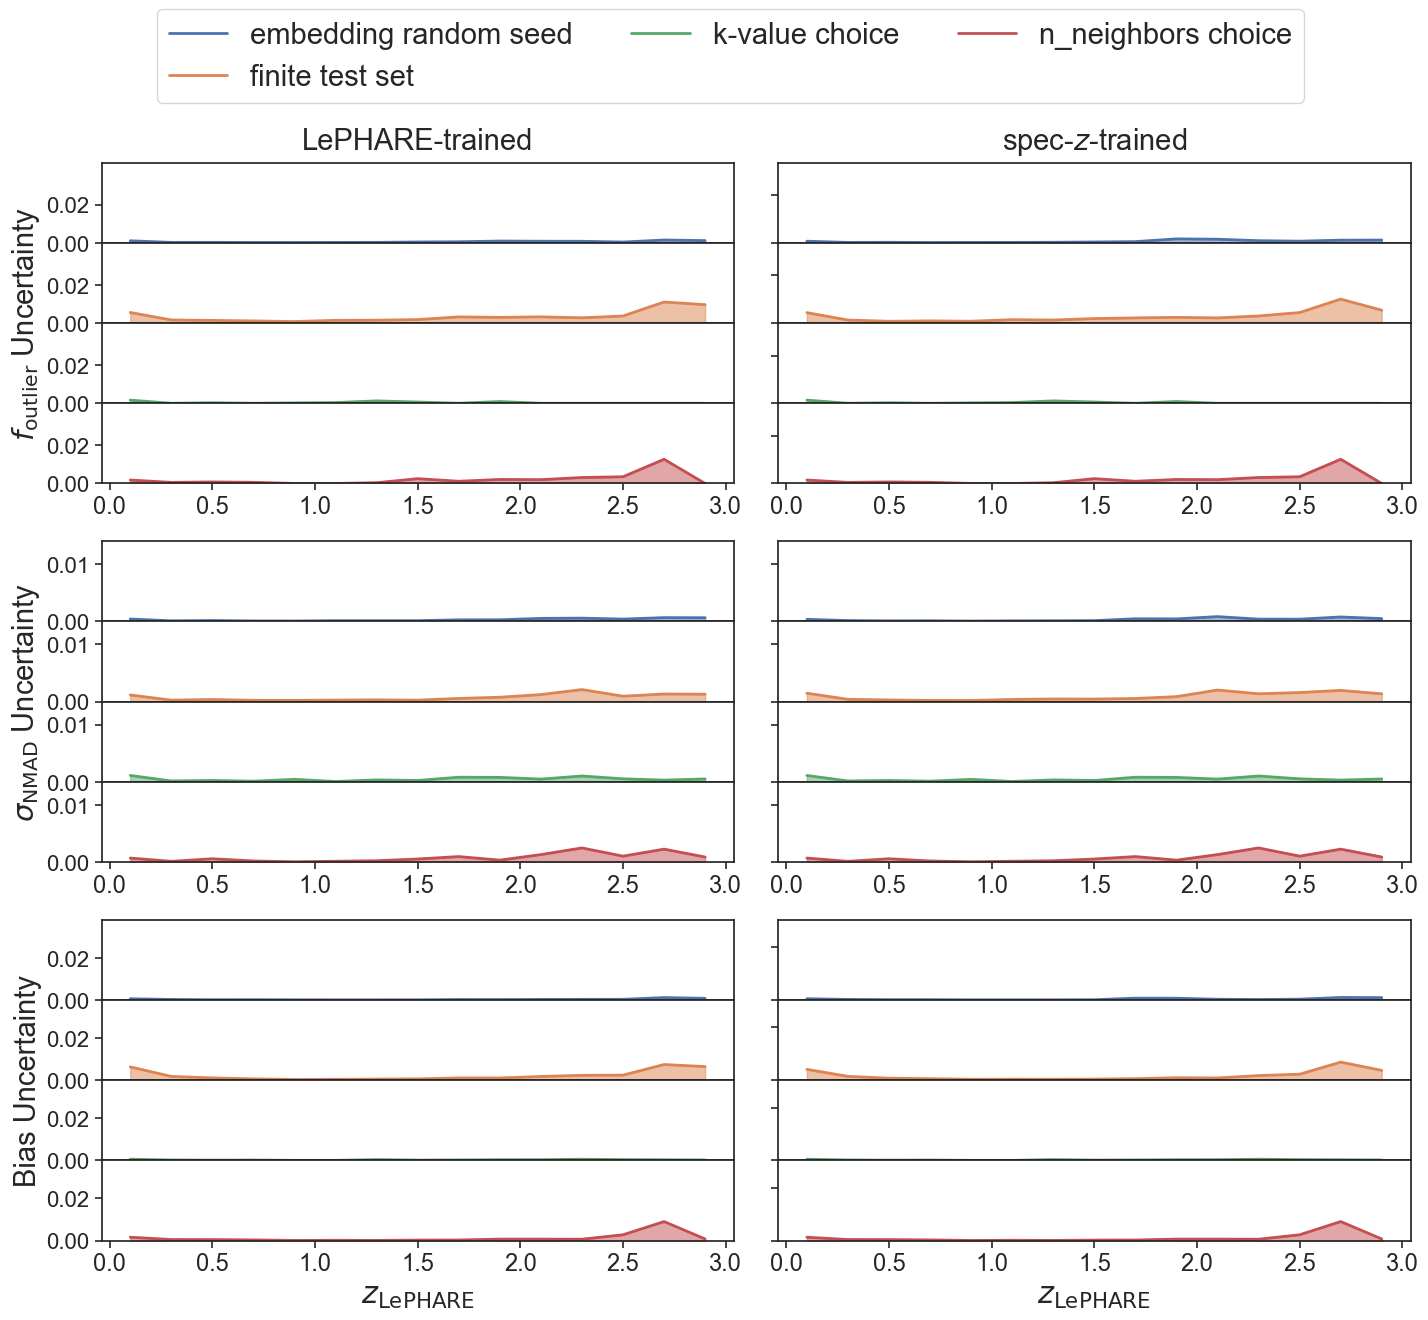

In [127]:
reload(umapz2)
umapz2.sandplot_split(uncs=umap_perf, unc_sources=unc_sources, labels=labels, 
                    cs=cs, ylims=ylims, filename='umap_uncs_260623.pdf')

In [197]:
train = 'LePHARE_trained'

In [198]:
umap_perf[train]['f_outlier']['unc_nn']

array([0.00181231, 0.00057239, 0.00081381, 0.00060482, 0.        ,
       0.        , 0.00039683, 0.00252893, 0.00116279, 0.00210526,
       0.002     , 0.003125  , 0.00351852, 0.01268074, 0.        ])

In [199]:
somrm_perf[train]['f_outlier']['unc_sigma']

array([0.010174  , 0.00072295, 0.00224212, 0.00105137, 0.00120119,
       0.00178172, 0.00128556, 0.00127937, 0.00648764, 0.00178818,
       0.00120697, 0.00322581, 0.0064777 , 0.01585498, 0.01550167])

In [200]:
somrm_perf[train]['f_outlier']['unc_learning_rate']

array([0.00942176, 0.00146851, 0.00223628, 0.00147342, 0.00101275,
       0.00248508, 0.00139532, 0.00244396, 0.00660403, 0.00107344,
       0.01110815, 0.00957661, 0.00539666, 0.01712213, 0.00934783])

In [201]:
somrm_perf[train]['f_outlier']['unc_size']

array([0.00670613, 0.00394574, 0.00132373, 0.00105136, 0.00081299,
       0.00138523, 0.00293893, 0.00265412, 0.00346405, 0.00671711,
       0.00079303, 0.00635081, 0.00931965, 0.00632876, 0.00819398])

In [202]:
labels = ['embedding random seed','finite test set','size choice','sigma choice','learning rate choice']
cs = ['C0', 'C1', 'C4', 'C5', 'C6']
unc_sources = ['rs', 'boots', 'size', 'sigma', 'learning_rate']
uncs = somrm_perf
ylims = [0.042, 0.014, 0.038]

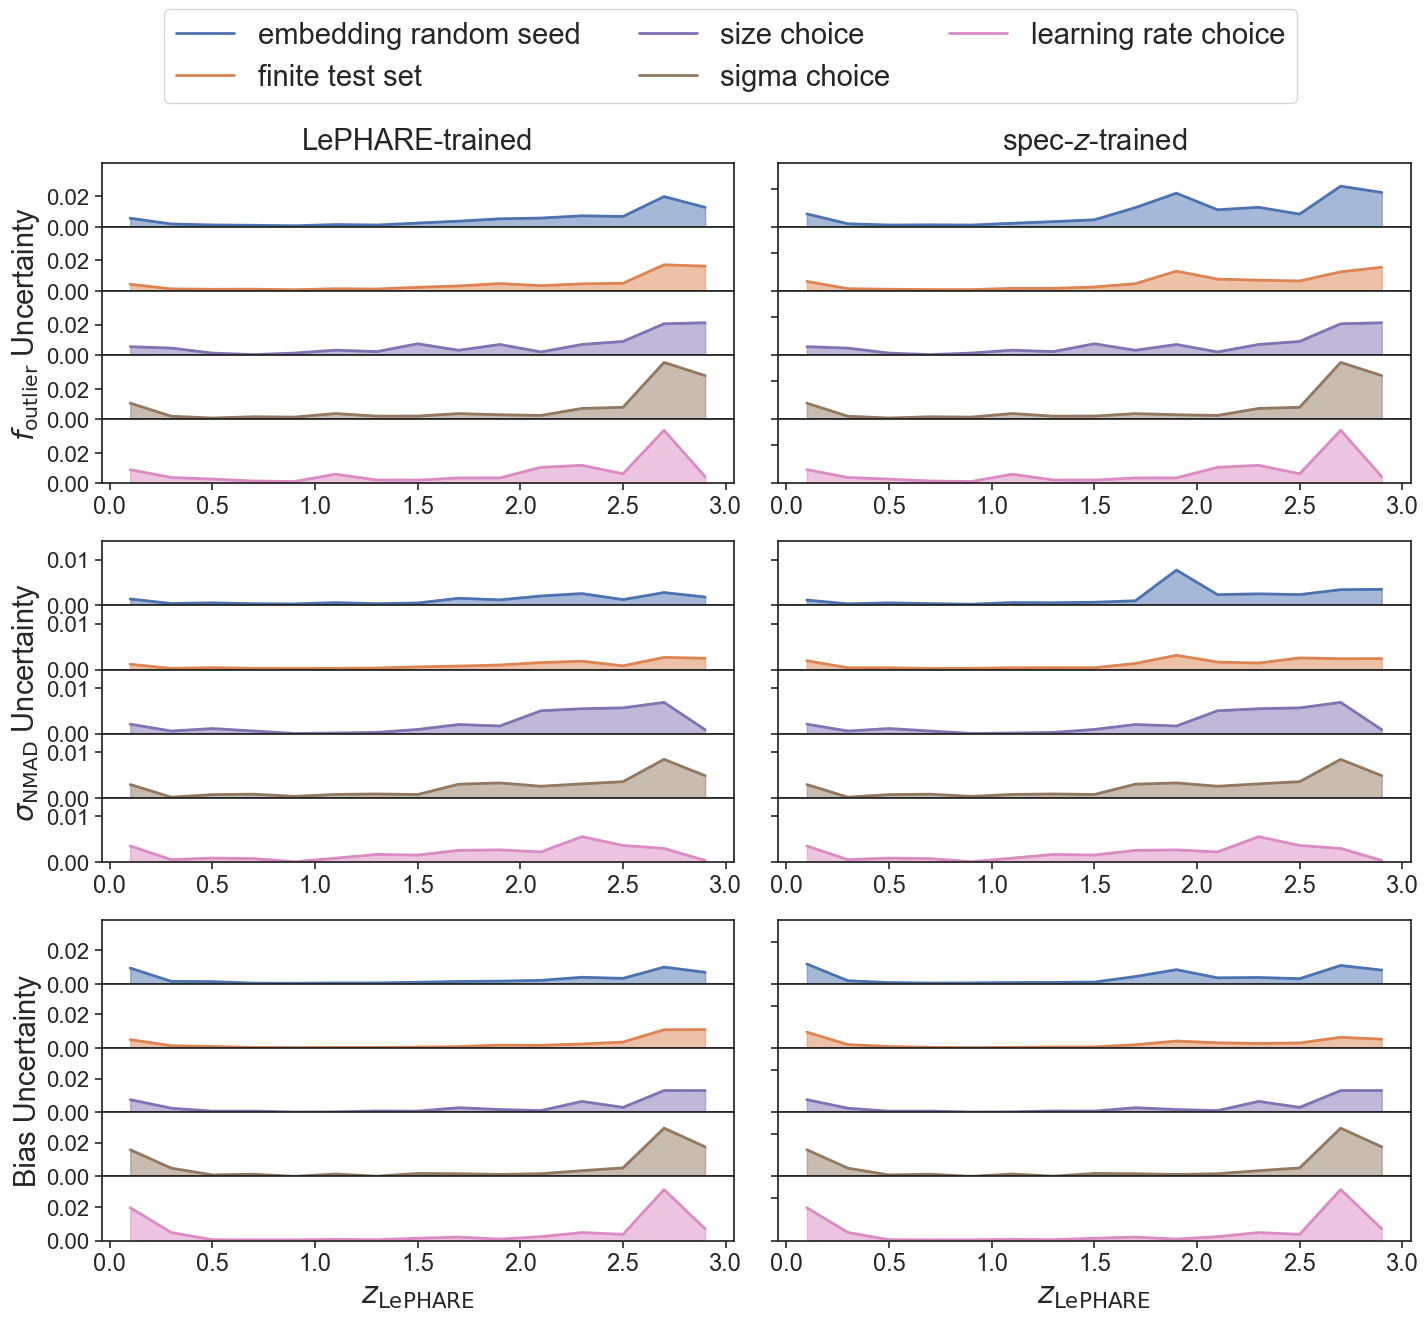

In [203]:
reload(umapz2)
umapz2.sandplot_split(uncs=somtco_perf, unc_sources=unc_sources, labels=labels, 
                    cs=cs, ylims=ylims, filename='somtco_uncs_260630.pdf')

In [204]:
print('hi')

hi


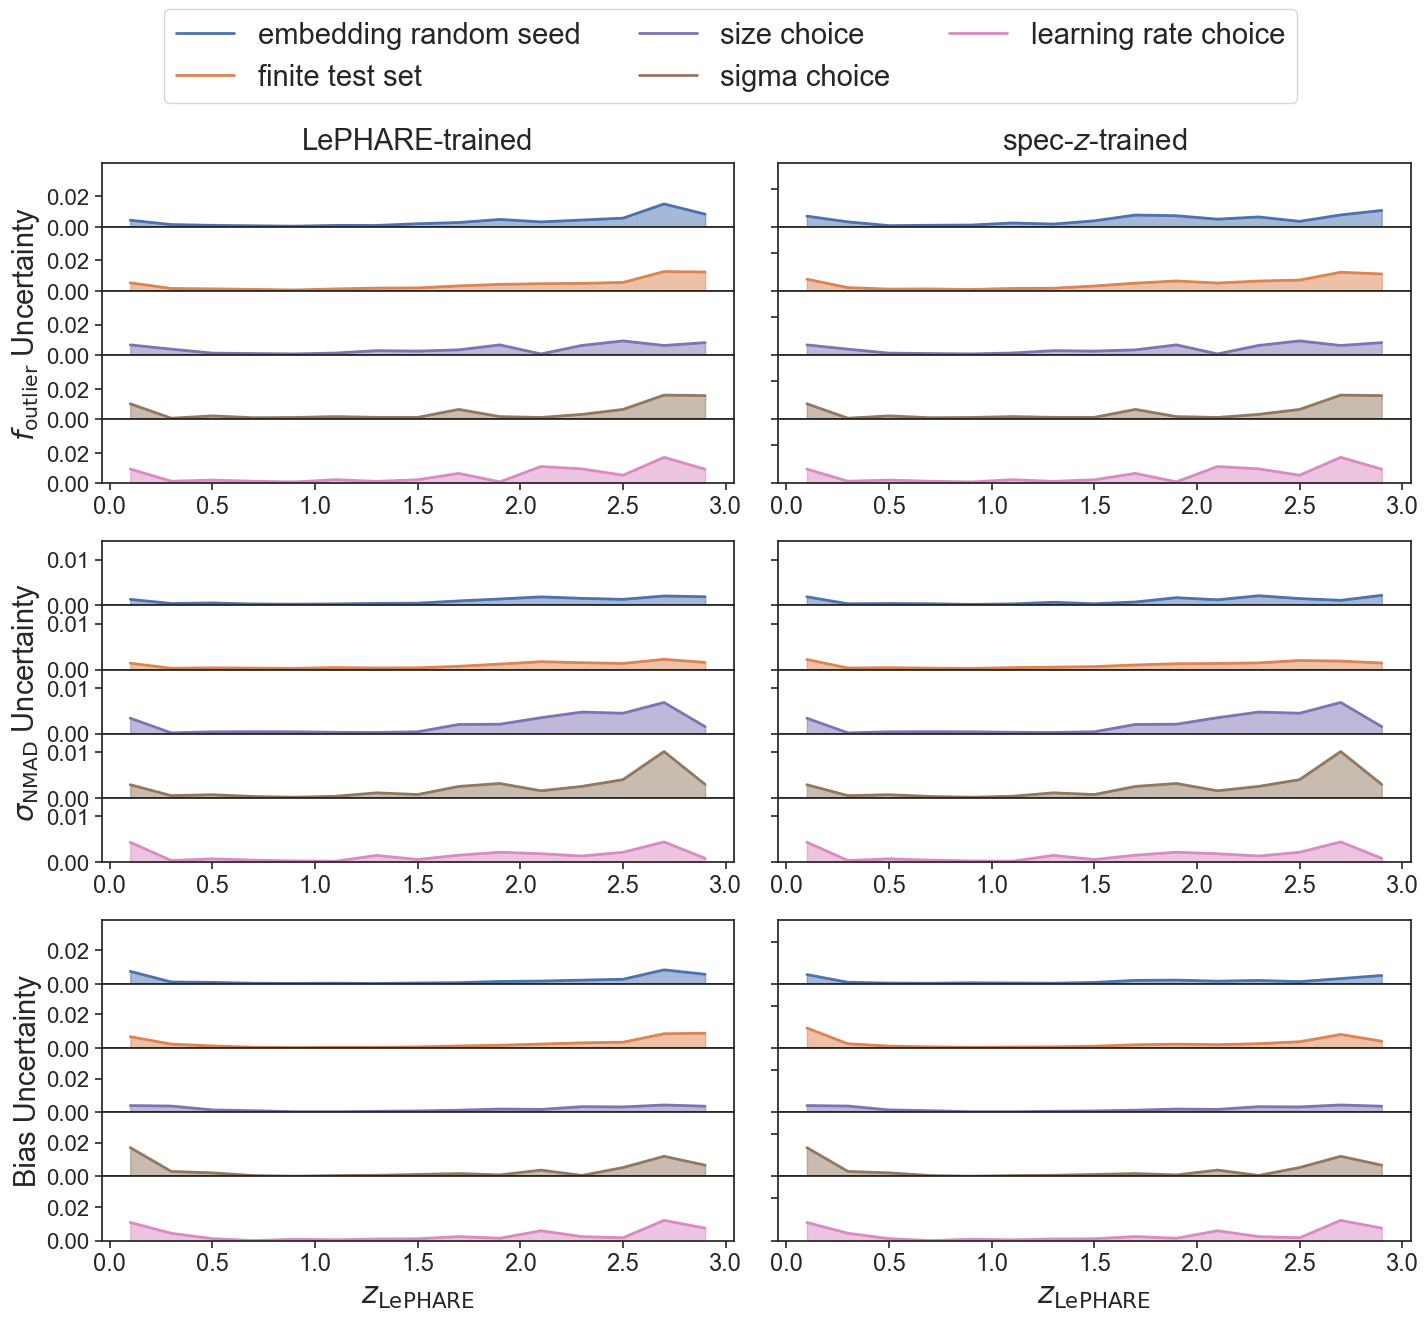

In [ ]:
reload(umapz2)
umapz2.sandplot_split(uncs=somrm_perf, unc_sources=unc_sources, labels=labels, 
                    cs=cs, ylims=ylims, filename='somrm_uncs_260630.pdf')

In [152]:
colors_errs

{'outliers': array([0.00596074, 0.00243963, 0.00101737, 0.00129403, 0.00115728,
        0.00148582, 0.0015748 , 0.00214501, 0.00357296, 0.00403013,
        0.00310643, 0.00516905, 0.00608838, 0.01327235, 0.00861514]),
 'nmads': array([0.00246901, 0.00050409, 0.00043055, 0.00022392, 0.0004082 ,
        0.00058101, 0.00040488, 0.00039268, 0.00068186, 0.00126861,
        0.00117186, 0.00268726, 0.00227146, 0.0023593 , 0.00167819]),
 'biases': array([0.00627502, 0.00192552, 0.00087751, 0.0004358 , 0.00040793,
        0.00051959, 0.00051725, 0.00069416, 0.00102919, 0.00122954,
        0.00117296, 0.00312393, 0.00367426, 0.00921942, 0.0057035 ]),
 'outliers_lp': array([0.00654543, 0.00261289, 0.00112442, 0.00082783, 0.00109823,
        0.00137145, 0.00153187, 0.00159443, 0.00393805, 0.00368313,
        0.00338179, 0.00405795, 0.00485783, 0.01332845, 0.01050265]),
 'nmads_lp': array([0.00214115, 0.00048755, 0.00042206, 0.00025966, 0.00041567,
        0.00054886, 0.00036225, 0.00030825, 0.0006

In [163]:
print('hi')

hi


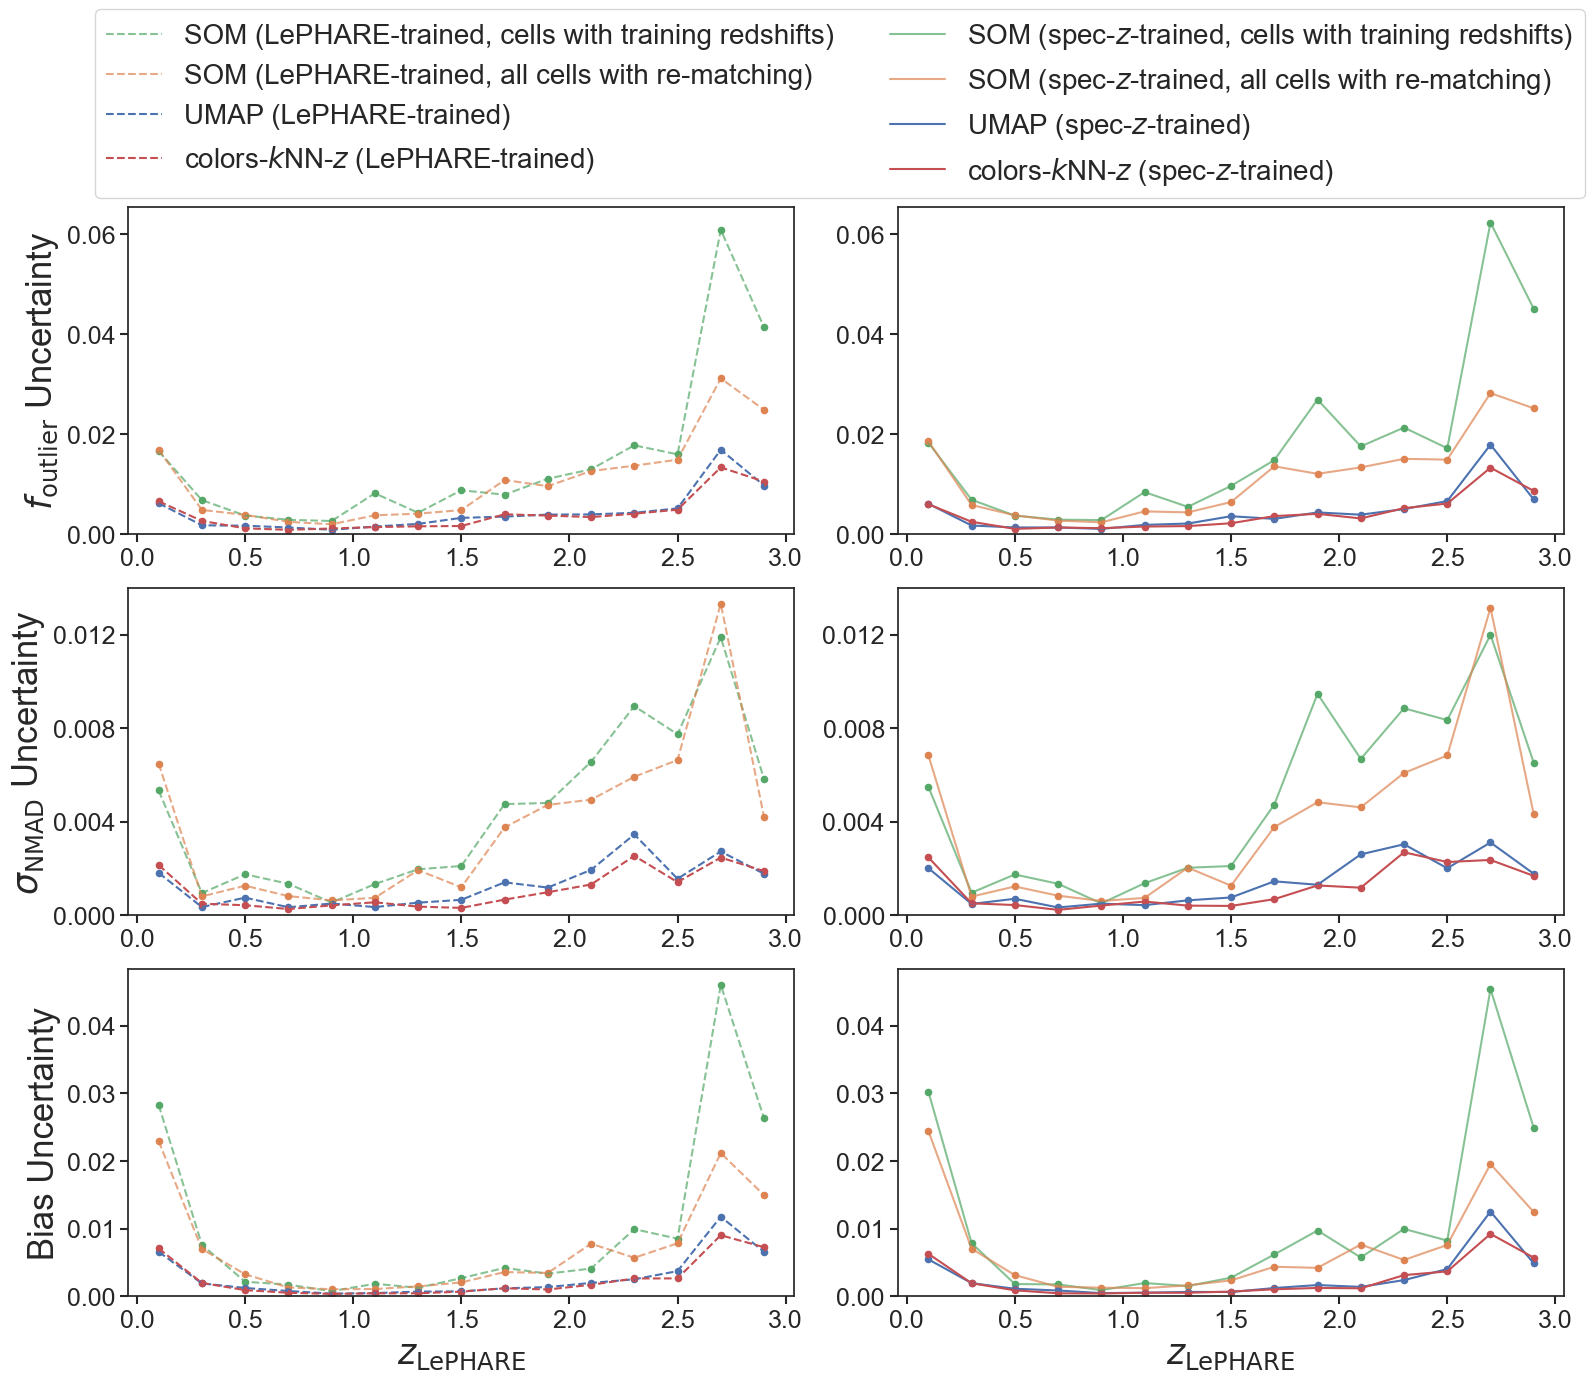

In [173]:
reload(umapz2)
umapz2.total_uncertainties(somrm_perf, somtco_perf, umap_perf, colors_perf=colors_errs, filename='total_uncertainties_260628.pdf')

In [ ]:
if 1:
    filename=None
    fig, axs = plt.subplots(3, 2, figsize=(16,12))
    trains = ['LePHARE', 'specz']
    c1, c2, c3, c4, c5 = cs
    l1, l2, l3, l4, l5 = labels
    bin_centers = uncs[trains[0]+'_trained']['bin_centers']
    metrics = ['f_outlier', 'nmad', 'bias']
    ylabels = [
        'Contribution to '+r'$f_\mathrm{outlier}$'+' Uncertainty',
        'Contribution to '+r'$\sigma_\mathrm{NMAD}$'+' Uncertainty',
        'Contribution to Bias Uncertainty'
    ]
    alpha=0.5

    #ticks
    for ax in axs.flat:
        ax.tick_params(axis='both', labelsize=18, length=6, width=1.5, 
                        bottom=True,top=False,left=True, right=False,
                        direction='out')
        #ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
    #axs[0,0].yaxis.set_major_locator(MultipleLocator(0.02))
    #axs[0,1].yaxis.set_major_locator(MultipleLocator(0.01))
    #axs[0,2].yaxis.set_major_locator(MultipleLocator(0.02))
    #axs[1,0].yaxis.set_major_locator(MultipleLocator(0.02))
    #axs[1,1].yaxis.set_major_locator(MultipleLocator(0.01))
    #axs[1,2].yaxis.set_major_locator(MultipleLocator(0.02))

    for i, train in enumerate(trains):
        for j, metric in enumerate(metrics):
            if i==0 and j==0:
                l1, l2, l3, l4, l5 = labels
            else:
                l1, l2, l3, l4, l5 = None, None, None, None, None
            if i==0:
                axs[j,i].set_ylabel(ylabels[j], fontsize=16)
            unc1, unc2, unc3, unc4, unc5 = [uncs[train+'_trained'][metric]['unc_'+unc_source] for unc_source in unc_sources]

            axs[j,i].plot(bin_centers, unc1, c=c1, ls='-', label=l1)
            axs[j,i].fill_between(bin_centers, unc1, alpha=alpha, color=c1)
            axs[j,i].plot(bin_centers, unc2+unc1, c=c2, ls='-', label=l2)
            axs[j,i].fill_between(bin_centers, unc2+unc1, y2=unc1, alpha=alpha, color=c2)
            axs[j,i].plot(bin_centers, unc3+unc2+unc1, c=c3, ls='-', label=l3)
            axs[j,i].fill_between(bin_centers, unc3+unc2+unc1,y2=unc2+unc1, alpha=alpha, color=c3)
            axs[j,i].plot(bin_centers, unc4+unc3+unc2+unc1, c=c4, ls='-', label=l4)
            axs[j,i].fill_between(bin_centers, unc4+unc3+unc2+unc1,y2=unc3+unc2+unc1, alpha=alpha, color=c4)
            axs[j,i].plot(bin_centers, unc5+unc4+unc3+unc2+unc1, c=c5, ls='-', label=l5)
            axs[j,i].fill_between(bin_centers, unc5+unc4+unc3+unc2+unc1,y2=unc4+unc3+unc2+unc1, alpha=alpha, color=c5)
            axs[j,i].set_ylim(0, ylims[j])
        axs[2,i].set_xlabel(r'$z_\mathrm{LePHARE}$', fontsize=25)
    fig.subplots_adjust(top=0.95)
    fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
                        ncols=3, borderaxespad=0., fontsize=18)
    fig.tight_layout()
    #fig.suptitle('Uncertainties Related to UMAP Embedding and Optimization', fontsize=14);
    if filename!=None:
        fig.savefig(filename, bbox_inches='tight')

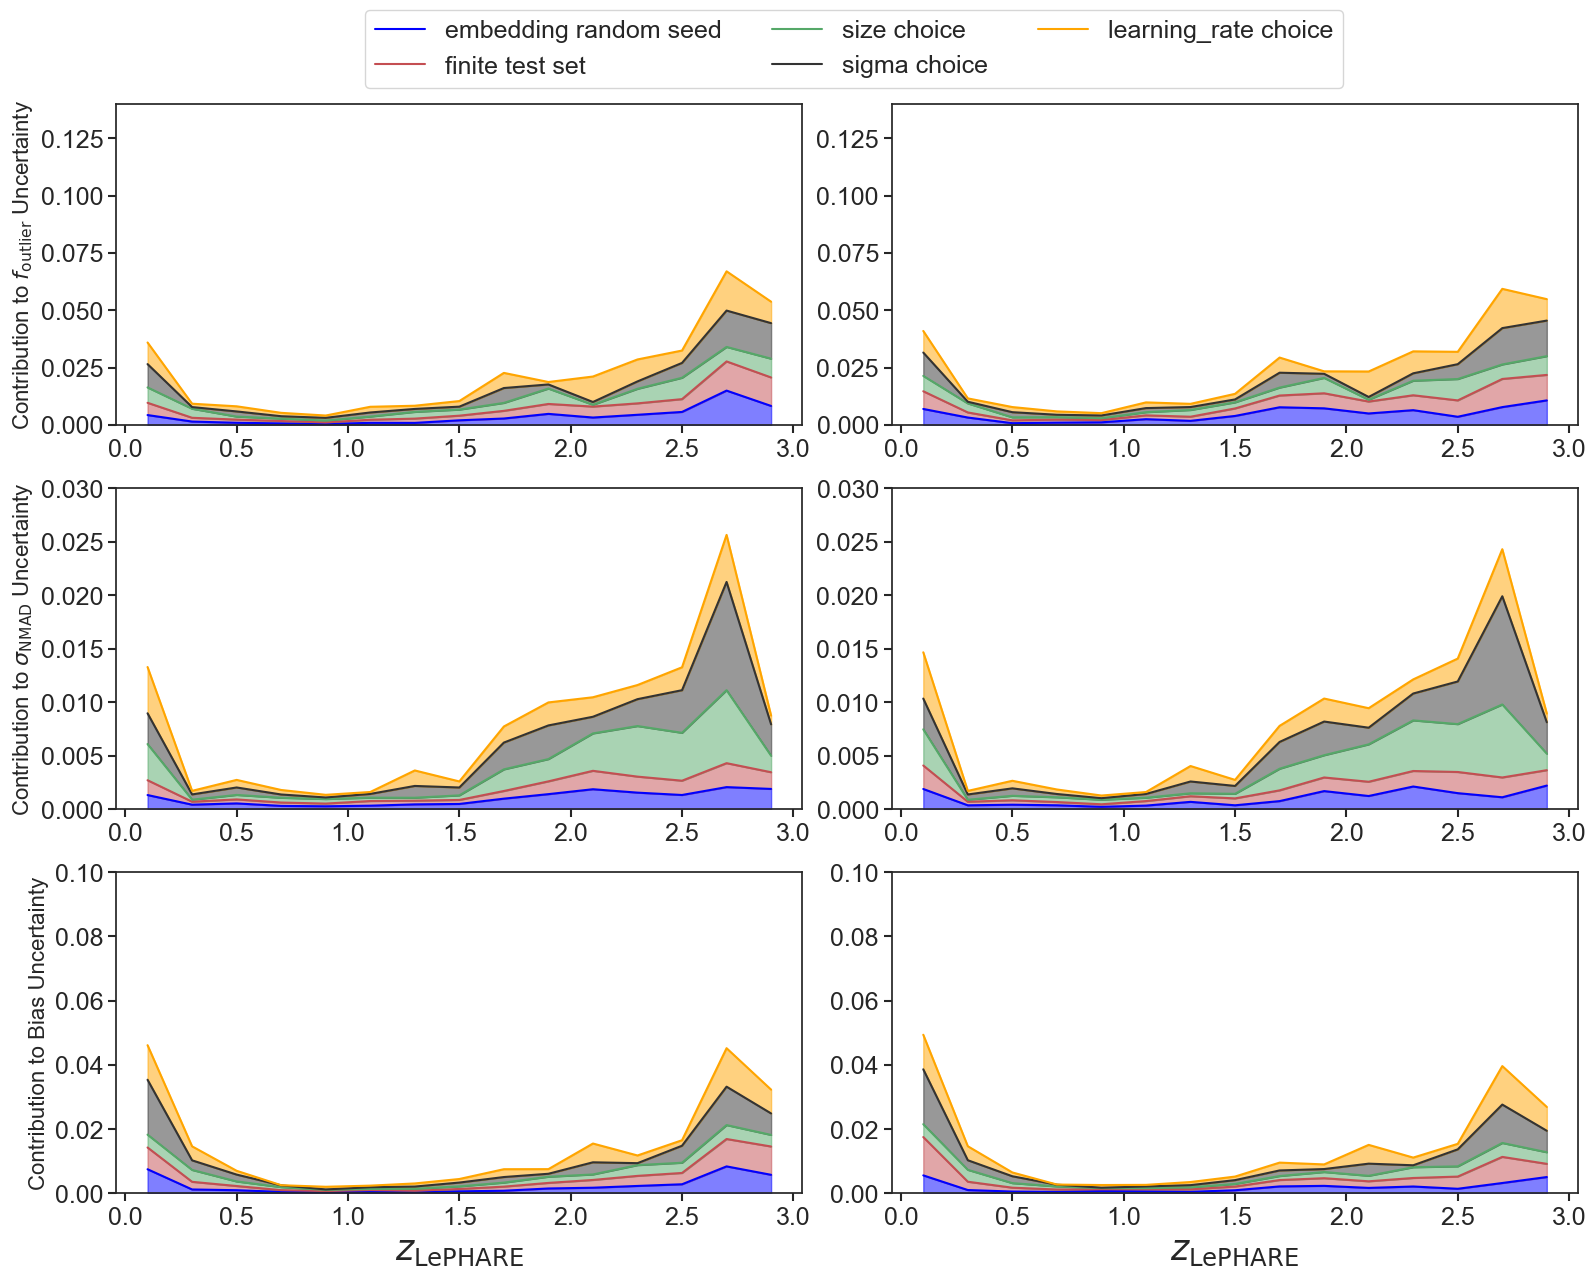

In [37]:
if 1:
    filename=None
    fig, axs = plt.subplots(3, 2, figsize=(16,12))
    trains = ['LePHARE', 'specz']
    c1, c2, c3, c4, c5 = cs
    l1, l2, l3, l4, l5 = labels
    bin_centers = uncs[trains[0]+'_trained']['bin_centers']
    metrics = ['f_outlier', 'nmad', 'bias']
    ylabels = [
        'Contribution to '+r'$f_\mathrm{outlier}$'+' Uncertainty',
        'Contribution to '+r'$\sigma_\mathrm{NMAD}$'+' Uncertainty',
        'Contribution to Bias Uncertainty'
    ]
    alpha=0.5

    #ticks
    for ax in axs.flat:
        ax.tick_params(axis='both', labelsize=18, length=6, width=1.5, 
                        bottom=True,top=False,left=True, right=False,
                        direction='out')
        #ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
    #axs[0,0].yaxis.set_major_locator(MultipleLocator(0.02))
    #axs[0,1].yaxis.set_major_locator(MultipleLocator(0.01))
    #axs[0,2].yaxis.set_major_locator(MultipleLocator(0.02))
    #axs[1,0].yaxis.set_major_locator(MultipleLocator(0.02))
    #axs[1,1].yaxis.set_major_locator(MultipleLocator(0.01))
    #axs[1,2].yaxis.set_major_locator(MultipleLocator(0.02))

    # OUTLIERS
    for i, train in enumerate(trains):
        for j, metric in enumerate(metrics):
            if i==0 and j==0:
                l1, l2, l3, l4, l5 = labels
            else:
                l1, l2, l3, l4, l5 = None, None, None, None, None
            if i==0:
                axs[j,i].set_ylabel(ylabels[j], fontsize=16)
            unc1, unc2, unc3, unc4, unc5 = [uncs[train+'_trained'][metric]['unc_'+unc_source] for unc_source in unc_sources]

            axs[j,i].plot(bin_centers, unc1, c=c1, ls='-', label=l1)
            axs[j,i].fill_between(bin_centers, unc1, alpha=alpha, color=c1)
            axs[j,i].plot(bin_centers, unc2+unc1, c=c2, ls='-', label=l2)
            axs[j,i].fill_between(bin_centers, unc2+unc1, y2=unc1, alpha=alpha, color=c2)
            axs[j,i].plot(bin_centers, unc3+unc2+unc1, c=c3, ls='-', label=l3)
            axs[j,i].fill_between(bin_centers, unc3+unc2+unc1,y2=unc2+unc1, alpha=alpha, color=c3)
            axs[j,i].plot(bin_centers, unc4+unc3+unc2+unc1, c=c4, ls='-', label=l4)
            axs[j,i].fill_between(bin_centers, unc4+unc3+unc2+unc1,y2=unc3+unc2+unc1, alpha=alpha, color=c4)
            axs[j,i].plot(bin_centers, unc5+unc4+unc3+unc2+unc1, c=c5, ls='-', label=l5)
            axs[j,i].fill_between(bin_centers, unc5+unc4+unc3+unc2+unc1,y2=unc4+unc3+unc2+unc1, alpha=alpha, color=c5)
            axs[j,i].set_ylim(0, ylims[j])
        axs[2,i].set_xlabel(r'$z_\mathrm{LePHARE}$', fontsize=25)
    fig.subplots_adjust(top=0.95)
    fig.legend(bbox_to_anchor=(0.03, 0.98, 1., .102), loc='center',
                        ncols=3, borderaxespad=0., fontsize=18)
    fig.tight_layout()
    #fig.suptitle('Uncertainties Related to UMAP Embedding and Optimization', fontsize=14);
    if filename!=None:
        fig.savefig(filename, bbox_inches='tight')

### global

In [48]:
with open("global_results_260515.pkl", "rb") as f:
    global_results = pickle.load(f)

In [56]:
with open("highz_results_260514.pkl", "rb") as f:
    highz_results = pickle.load(f)

In [57]:
highz_results

{'LePHARE_trained': {'f_outlier': {'umap_value': 0.03773720979819137,
   'umap_unc': 0.0016386638243462022,
   'somrm_value': 0.05208268007876682,
   'somrm_unc': 0.003246204459327517,
   'somtco_value': 0.03683025038047243,
   'somtco_unc': 0.004004299190582874,
   'colors_value': 0.03774661666394913,
   'colors_unc': 0.0017038407242859596},
  'nmad': {'umap_value': 0.028018160090971158,
   'umap_unc': 0.0004835886723901137,
   'somrm_value': 0.03343374612941247,
   'somrm_unc': 0.0007288646904592968,
   'somtco_value': 0.03154873728295198,
   'somtco_unc': 0.0008630123256154403,
   'colors_value': 0.02555118905599541,
   'colors_unc': 0.0005288108073644205},
  'bias': {'umap_value': -0.023038397028937455,
   'umap_unc': 0.0008609537369490824,
   'somrm_value': -0.026788809426824767,
   'somrm_unc': 0.0020911772865015174,
   'somtco_value': -0.01871159811521777,
   'somtco_unc': 0.0018026762196415027,
   'colors_value': -0.025065439871725097,
   'colors_unc': 0.0010079836830930574}},


In [61]:
highz_results['LePHARE_trained']['f_outlier']

{'umap_value': 0.03773720979819137,
 'umap_unc': 0.0016386638243462022,
 'somrm_value': 0.05208268007876682,
 'somrm_unc': 0.003246204459327517,
 'somtco_value': 0.03683025038047243,
 'somtco_unc': 0.004004299190582874,
 'colors_value': 0.03774661666394913,
 'colors_unc': 0.0017038407242859596}

In [62]:
highz_results['LePHARE_trained']['nmad']

{'umap_value': 0.028018160090971158,
 'umap_unc': 0.0004835886723901137,
 'somrm_value': 0.03343374612941247,
 'somrm_unc': 0.0007288646904592968,
 'somtco_value': 0.03154873728295198,
 'somtco_unc': 0.0008630123256154403,
 'colors_value': 0.02555118905599541,
 'colors_unc': 0.0005288108073644205}

In [63]:
highz_results['LePHARE_trained']['bias']

{'umap_value': -0.023038397028937455,
 'umap_unc': 0.0008609537369490824,
 'somrm_value': -0.026788809426824767,
 'somrm_unc': 0.0020911772865015174,
 'somtco_value': -0.01871159811521777,
 'somtco_unc': 0.0018026762196415027,
 'colors_value': -0.025065439871725097,
 'colors_unc': 0.0010079836830930574}

### old stuff

In [14]:
umap_perf['specz_trained']['outliers_mean'] = umap_perf['specz_trained']['f_outlier']['mean'].copy()
somtco_perf['specz_trained']['outliers_mean'] = somtco_perf['specz_trained']['f_outlier']['mean'].copy()
somrm_perf['specz_trained']['outliers_mean'] = somrm_perf['specz_trained']['f_outlier']['mean'].copy()

umap_perf['specz_trained']['nmads_mean'] = umap_perf['specz_trained']['nmad']['mean'].copy()
somtco_perf['specz_trained']['nmads_mean'] = somtco_perf['specz_trained']['nmad']['mean'].copy()
somrm_perf['specz_trained']['nmads_mean'] = somrm_perf['specz_trained']['nmad']['mean'].copy()

umap_perf['specz_trained']['biases_mean'] = umap_perf['specz_trained']['bias']['mean'].copy()
somtco_perf['specz_trained']['biases_mean'] = somtco_perf['specz_trained']['bias']['mean'].copy()
somrm_perf['specz_trained']['biases_mean'] = somrm_perf['specz_trained']['bias']['mean'].copy()

umap_perf['LePHARE_trained']['outliers_mean'] = umap_perf['LePHARE_trained']['f_outlier']['mean'].copy()
somtco_perf['LePHARE_trained']['outliers_mean'] = somtco_perf['LePHARE_trained']['f_outlier']['mean'].copy()
somrm_perf['LePHARE_trained']['outliers_mean'] = somrm_perf['LePHARE_trained']['f_outlier']['mean'].copy()

umap_perf['LePHARE_trained']['nmads_mean'] = umap_perf['LePHARE_trained']['nmad']['mean'].copy()
somtco_perf['LePHARE_trained']['nmads_mean'] = somtco_perf['LePHARE_trained']['nmad']['mean'].copy()
somrm_perf['LePHARE_trained']['nmads_mean'] = somrm_perf['LePHARE_trained']['nmad']['mean'].copy()

umap_perf['LePHARE_trained']['biases_mean'] = umap_perf['LePHARE_trained']['bias']['mean'].copy()
somtco_perf['LePHARE_trained']['biases_mean'] = somtco_perf['LePHARE_trained']['bias']['mean'].copy()
somrm_perf['LePHARE_trained']['biases_mean'] = somrm_perf['LePHARE_trained']['bias']['mean'].copy()

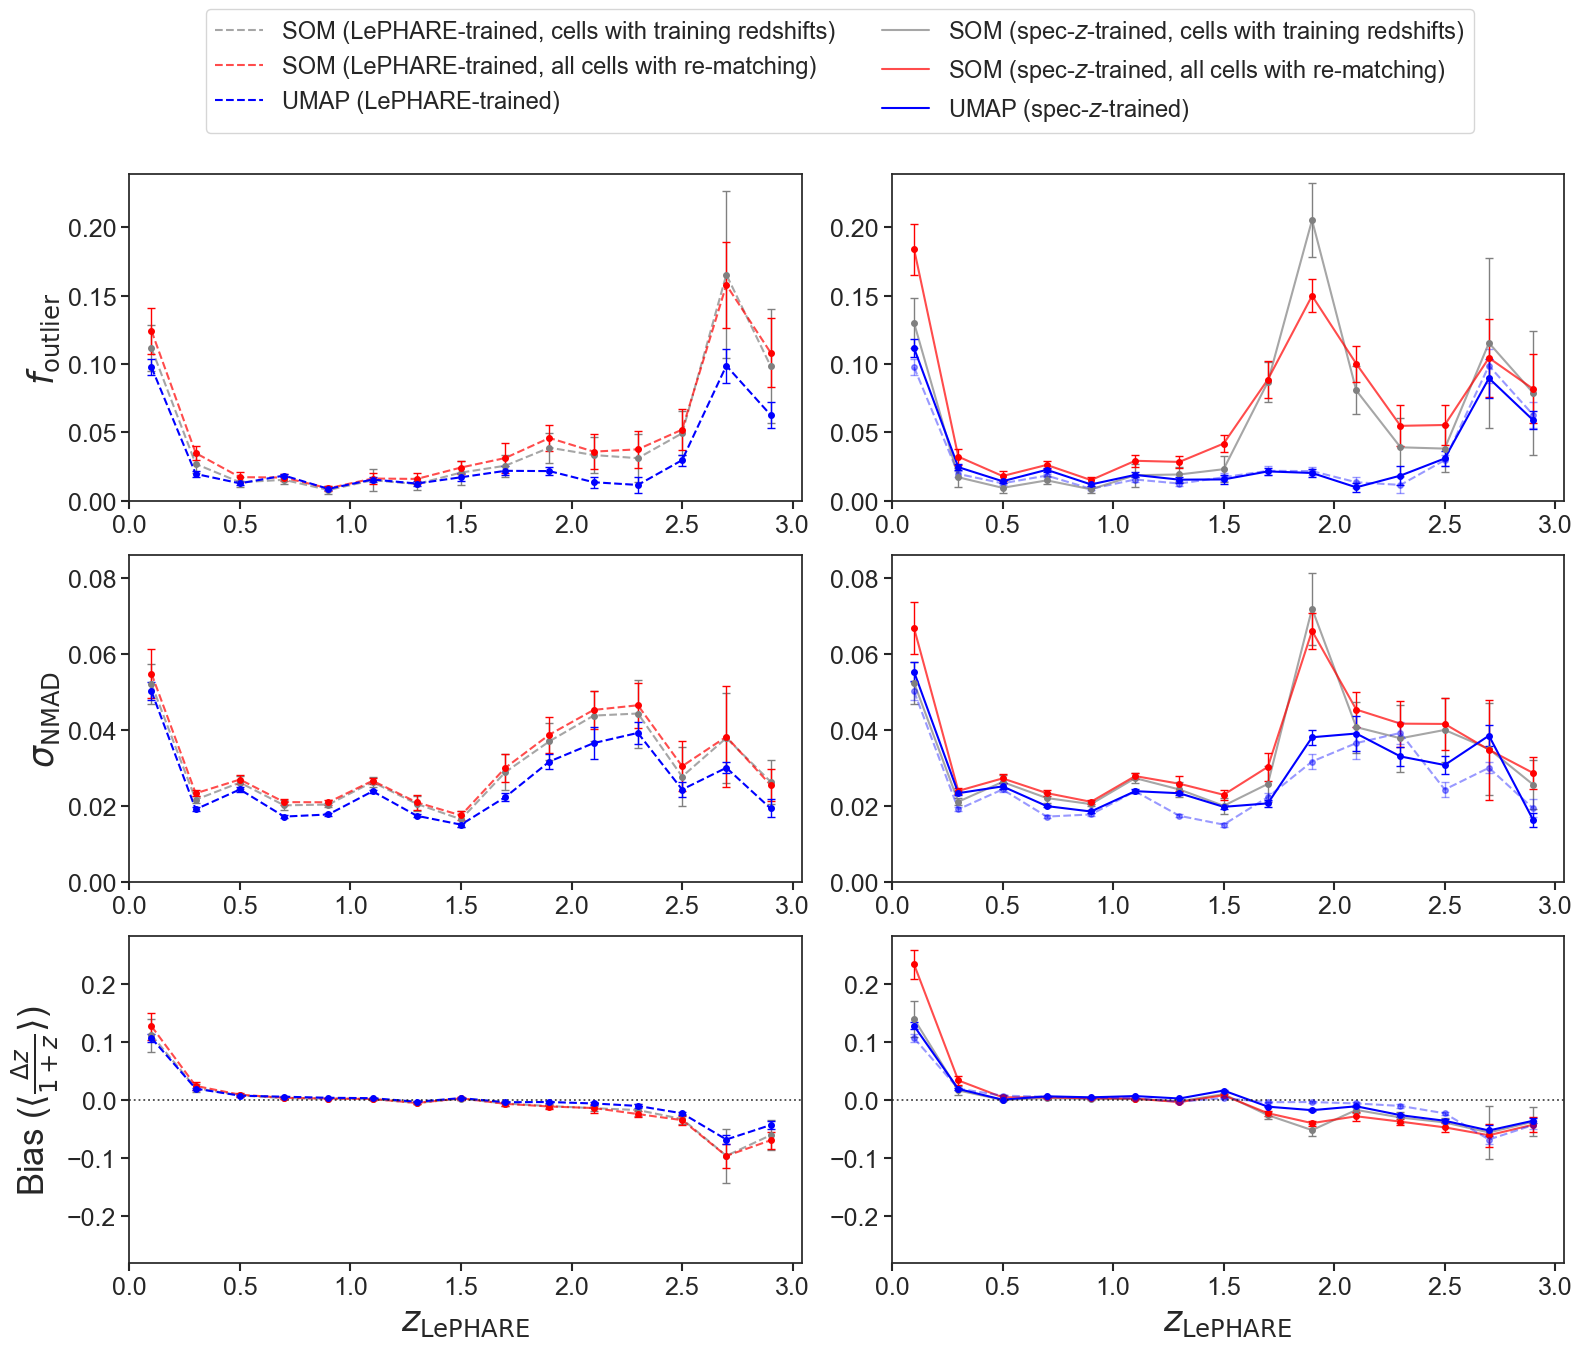

In [25]:
reload(umapz2)
umapz2.z_binned_stats2(som_nrm_s=somtco_perf['specz_trained'], som_rm_s=somrm_perf['specz_trained'], 
                    umap_s=umap_perf['specz_trained'], som_nrm_lp=somtco_perf['LePHARE_trained'], 
                    som_rm_lp=somrm_perf['LePHARE_trained'], umap_lp=umap_perf['LePHARE_trained'], 
                    umap_errs=umap_errs, som_rm_errs=som_rm_errs, som_nrm_errs=som_nrm_errs,
                    i_vals='TEST_Z', t_vals='lp_photoz', bin_min=0.0, bin_max=3.0, bin_size=0.2, filename=None)

In [26]:
with open("rs_binned_results_umap_s_260422.pkl", "rb") as f:
    umap_s = pickle.load(f)

with open("rs_binned_results_umap_lp_260422.pkl", "rb") as f:
    umap_lp = pickle.load(f)

with open("colors_binned_260513.pkl", "rb") as f:
    colors_binned = pickle.load(f)

In [150]:
colors_perf['specz_trained']

{'f_outlier': {'f_outlier': array([0.1321599 , 0.01936547, 0.01103921, 0.02195414, 0.00981729,
         0.01568154, 0.01191352, 0.01671868, 0.03650734, 0.03688676,
         0.02557856, 0.03104027, 0.05492424, 0.11424542, 0.0534846 ]),
  'unc_k': array([0.00338415, 0.00187956, 0.00028052, 0.00021231, 0.00080904,
         0.000369  , 0.00087471, 0.00059172, 0.00116279, 0.00198126,
         0.        , 0.00099734, 0.00238095, 0.00416667, 0.004     ]),
  'unc_boots': array([0.00490693, 0.00155533, 0.00097794, 0.0012765 , 0.0008275 ,
         0.00143927, 0.00130953, 0.00206178, 0.00337846, 0.00350949,
         0.00310643, 0.00507192, 0.00560352, 0.01260135, 0.00763025])},
 'nmad': {'nmad': array([0.05218472, 0.01907796, 0.02229971, 0.01805919, 0.01567329,
         0.02336702, 0.02187221, 0.0192728 , 0.02297983, 0.0509541 ,
         0.03600247, 0.03253099, 0.03212445, 0.03854323, 0.01805915]),
  'unc_k': array([1.97704952e-03, 4.38248418e-04, 2.84294437e-04, 1.15099580e-04,
         3.753188

In [86]:
umap_s = umap_perf['specz_trained'].copy()
umap_lp = umap_perf['LePHARE_trained'].copy()

In [89]:
colors_s = colors_perf['specz_trained'].copy()
colors_lp = colors_perf['LePHARE_trained'].copy()

In [94]:
umap_perf['LePHARE_trained']

{'f_outlier': {'mean': array([0.09952313, 0.01986206, 0.01321456, 0.01875847, 0.00906062,
         0.01530466, 0.01283648, 0.01852274, 0.02150813, 0.02246835,
         0.01319876, 0.01203106, 0.02947435, 0.09847884, 0.06265263]),
  'unc': array([0.00615357, 0.00173748, 0.00164861, 0.00129245, 0.00084122,
         0.00148496, 0.00201711, 0.00322301, 0.00347044, 0.00387962,
         0.00391071, 0.00424471, 0.00511932, 0.01686448, 0.00970077]),
  'unc_k': array([0.00165301, 0.        , 0.00026002, 0.        , 0.00019531,
         0.00035971, 0.00125237, 0.00065359, 0.        , 0.00091743,
         0.        , 0.        , 0.        , 0.        , 0.        ]),
  'unc_nn': array([0.00181231, 0.00057239, 0.00081381, 0.00060482, 0.        ,
         0.        , 0.00039683, 0.00252893, 0.00116279, 0.00210526,
         0.002     , 0.003125  , 0.00351852, 0.01268074, 0.        ]),
  'unc_rs': array([0.00107587, 0.0002432 , 0.00026036, 0.00018966, 0.00018012,
         0.0002241 , 0.00025586, 0.000

### colors plot

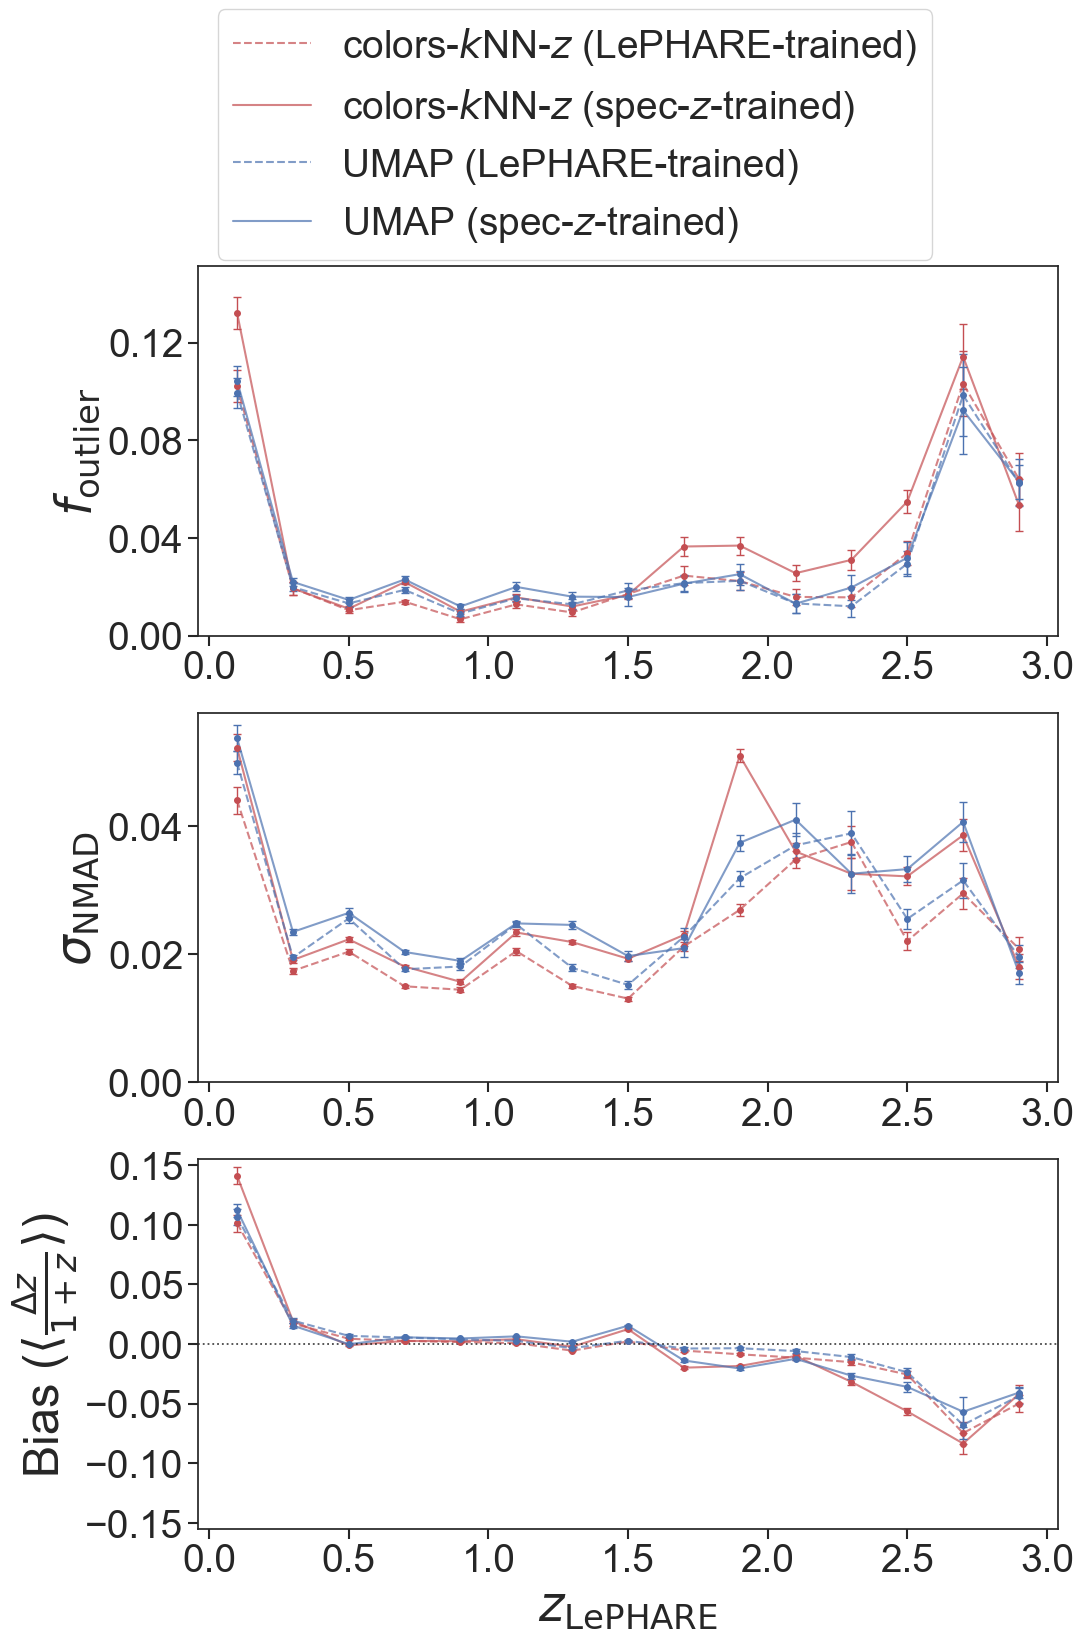

In [177]:
reload(umapz2)
umapz2.z_binned_umap_vs_colors2(umap_perf=umap_perf, colors_perf=colors_perf, 
                                umap_errs=umap_errs, colors_errs=colors_errs, filename='zbinned_vs_colors_260628.pdf')

In [8]:
umap_test_lp = umapz2.interpolator(df1=splits['train_lp'], df2=splits['test_lp'], map='UMAPnn80', dim=3,
                                    nn=15, calc='median', z_true='lp_photoz')
umap_test_spec = umapz2.interpolator(df1=splits['train_spec'], df2=splits['test_spec'], map='UMAPnn80', dim=3,
                                    nn=15, calc='median', z_true='specz')
som_test_lp = umapz2.som_rematch(df1=splits['train_lp'], df2=splits['test_lp'], map='SOMrs3', zlabel='lp_photoz', nn=50)
som_test_spec = umapz2.som_rematch(df1=splits['train_spec'], df2=splits['test_spec'], map='SOMrs3', zlabel='specz', nn=50)

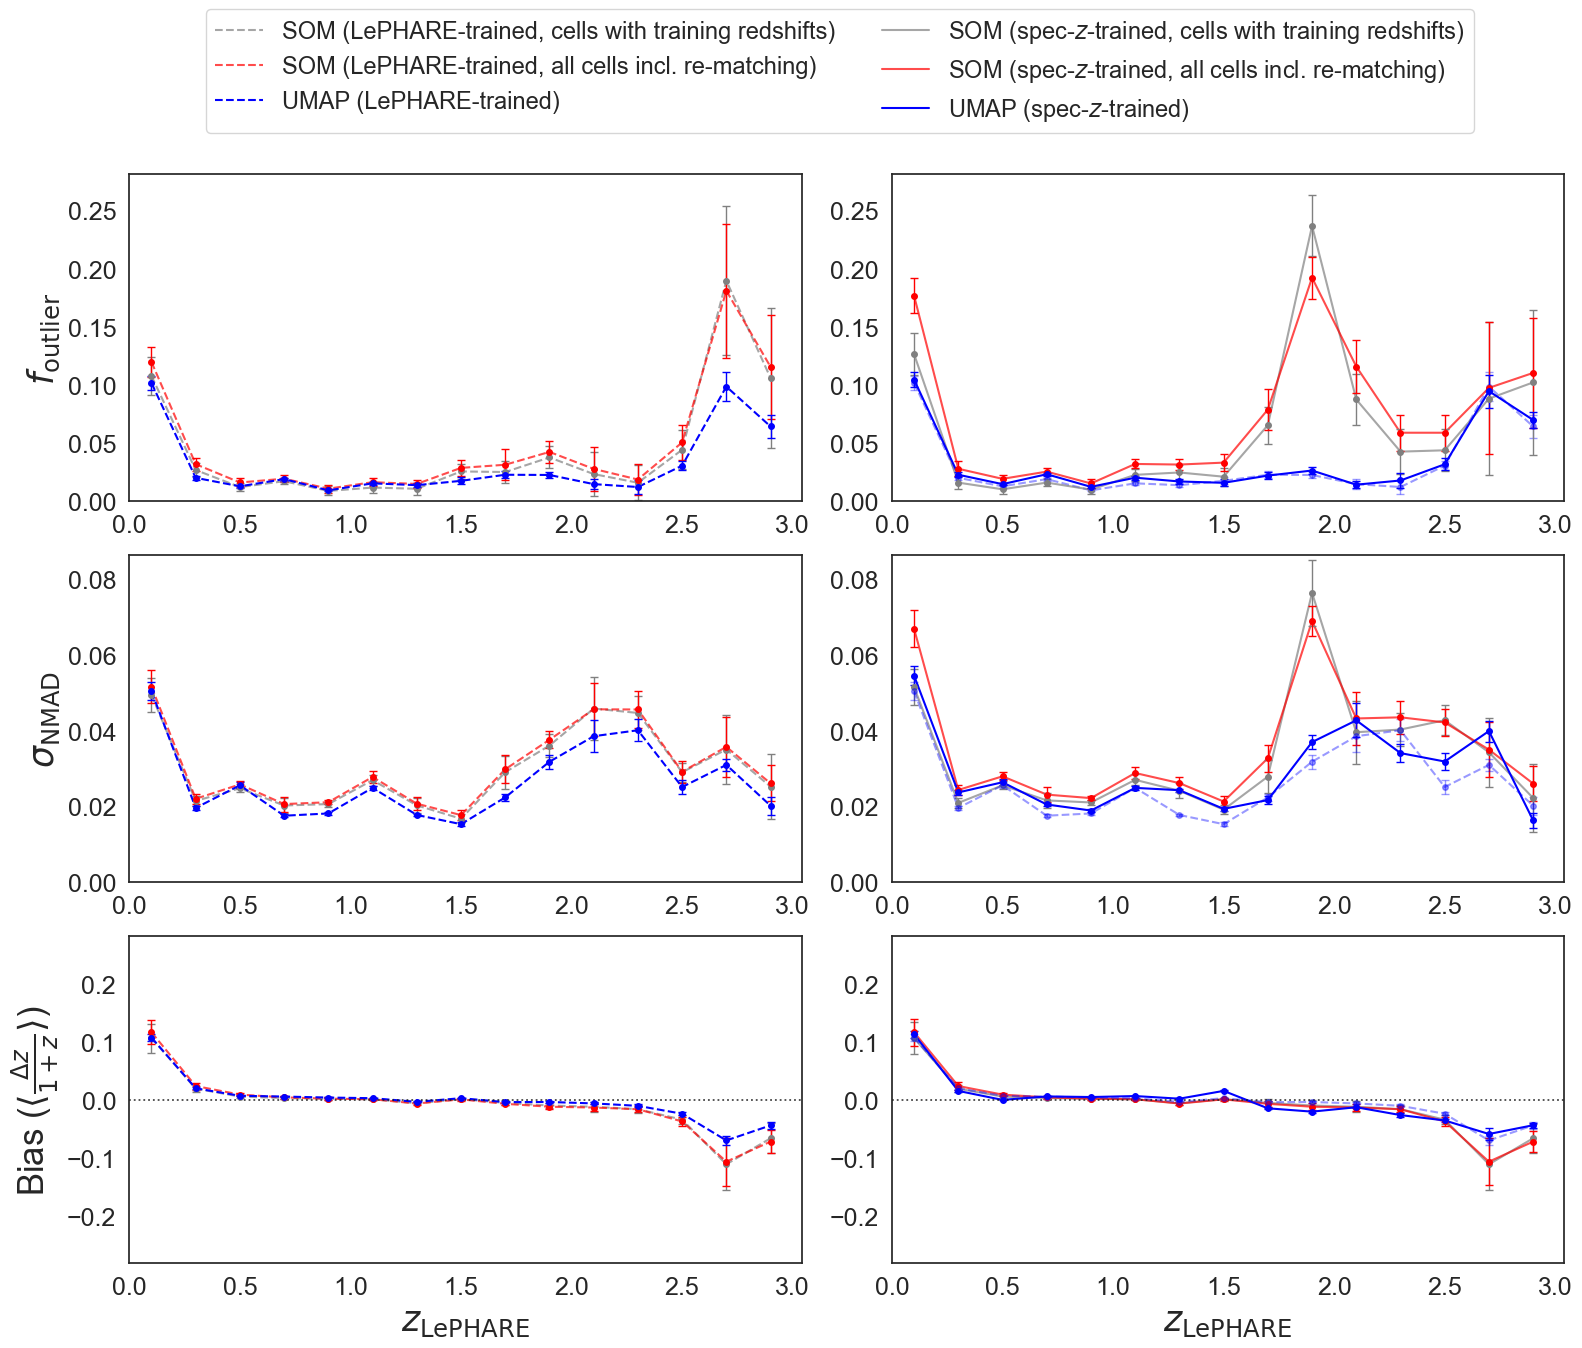

In [11]:
reload(umapz2)
umapz2.z_binned_stats(fullcat_lp=splits['test_lp'], fullcat_spec=splits['test_spec'], 
                umap_test_lp=umap_test_lp, umap_test_spec=umap_test_spec, som_test_lp=som_test_lp, 
                som_test_spec=som_test_spec, umap_errs=umap_errs, som_rm_errs=som_rm_errs, som_nrm_errs=som_nrm_errs,
                i_vals='TEST_Z', t_vals='lp_photoz', bin_min=0.0, bin_max=3.0, bin_size=0.2, filename=None)